# 15 · Where the large deltas are correct

Notebook 14 showed that, for near-identical pairs, the models mostly score both members alike. This notebook studies the opposite cases: pairs where a model *does* separate the two members by a large margin and gets it **right**, ranking the active clearly above its near-identical inactive partner.

**Definition.** For a modality, the delta is the active's percentile rank minus the inactive's, over the whole eval set. A call is **right** if the delta is above +0.3, **wrong** if below -0.3, and a **tie** otherwise. This threshold is defined from the models' own scores, not from the labels, and it depends on the score scale; notebook 16 anchors the comparison on the binary label instead. The primary subject is the Boltz-2 affinity head, taken as right when either the dataset score or our No-FT score clears +0.3 with neither below -0.3. Boltzina, Boltzina docking and head-FT are examined alongside.

**The question is not only 'where is it right' but 'why'**, and in particular how much of it is the trivial explanation that the active is the larger or greasier molecule. Every section therefore keeps size and lipophilicity in view, and reports how many *independent* actives and chemical series support each claim, because one series of 52 compounds supplies most of the pairs (see notebook 14).

In [1]:

import json, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")
from IPython.display import display
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; CL="#d62728"; CO="#2a78d6"; NEU="#666666"; GRN="#1baf7a"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); A=ROOT/"results/analysis/588689/cliffs"
P=pd.read_csv(A/"pairs.csv"); M=pd.read_csv(A/"compounds.csv"); Z=np.load(A/"contacts.npz",allow_pickle=True)
AU=pd.read_csv(A/"modality_auroc.csv").set_index("modality")
MODS=[("score_boltz2","Boltz-2 (dataset score)"),("base_noft","Boltz-2 No-FT (our pipeline)"),
      ("ft300","Boltz-2 head-FT N=300 (5-seed)"),("score_boltzina","Boltzina"),
      ("score_boltzina_recycle1","Boltzina recycle-1"),("score_boltzina_mask","Boltzina mask"),
      ("docking_score_boltzina","Boltzina docking (3 identical columns)"),("score_gnina","GNINA"),("score_vina","AutoDock Vina")]
MN=dict(MODS)
CONF=[("ligand_iptm","ligand ipTM (= ipTM here)"),("complex_plddt","complex pLDDT"),("confidence_score","overall confidence"),
      ("complex_pde","complex PDE"),("disagree_noft","two-head disagreement (No-FT)"),("disagree_ft300","two-head disagreement (FT)"),
      ("cross_seed_sd","cross-seed SD (FT)")]
Mi=M.set_index("id"); rng=np.random.default_rng(0)
# ---- orient pairs: a = the ACTIVE member for cliffs; controls (both active) get a random a/b orientation
flip=(P.kind=="conserved")&(rng.random(len(P))<0.5)
swaps=[("id_a","id_b"),("smiles_a","smiles_b"),("diff_a_atoms","diff_b_atoms"),("mcs_a","mcs_b"),("ia","ib")]
swaps+=[(c,"b_"+c[2:]) for c in P.columns if c.startswith("a_") and ("b_"+c[2:]) in P.columns]
for x,y in swaps:
    tmp=P.loc[flip,x].copy(); P.loc[flip,x]=P.loc[flip,y].values; P.loc[flip,y]=tmp.values
def side(col,ids): return Mi[col].reindex(ids).values
for m,_ in MODS: P["d_"+m]=side("pct_"+m,P.id_a)-side("pct_"+m,P.id_b)
for f,_ in CONF: P["c_"+f]=side(f,P.id_a)-side(f,P.id_b)
rowof={i:k for k,i in enumerate(Z["ids"])}; MD=Z["mind"]
ma=MD[[rowof[i] for i in P.id_a]]; mb=MD[[rowof[i] for i in P.id_b]]
ca_,cb_=(ma<=5.0),(mb<=5.0)
inter=(ca_&cb_).sum(1); uni=(ca_|cb_).sum(1)
P["pose_jdist"]=np.where(np.isnan(ma).any(1)|np.isnan(mb).any(1),np.nan,1-inter/np.maximum(uni,1))
P["pose_absdiff"]=np.nanmean(np.abs(ma-mb),axis=1)
PROPS=[("MW","molecular weight"),("heavy","heavy atoms"),("logP","logP"),("TPSA","polar surface area"),("HBD","H-bond donors"),
       ("HBA","H-bond acceptors"),("rotb","rotatable bonds"),("arom_rings","aromatic rings"),("fsp3","fraction sp3")]
for p,_ in PROPS: P["dp_"+p]=P["a_"+p]-P["b_"+p]
_raw=pd.read_csv(ROOT/"data/mf-pcba_test/588689.csv"); ZS=pd.Series(_raw["SD Z-score"].values,index="588689_"+_raw.CID.astype(str))
ACT_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==1]; INA_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==0]
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
_ids=pd.unique(np.concatenate([P.id_a.values,P.id_b.values])); _ix={k:i for i,k in enumerate(_ids)}
_g=coo_matrix((np.ones(len(P)),([_ix[i] for i in P.id_a],[_ix[i] for i in P.id_b])),shape=(len(_ids),len(_ids)))
_nc,_lab=connected_components(_g,directed=False); P["series"]=[_lab[_ix[i]] for i in P.id_a]
P["simbin"]=pd.cut(P.sim,[0.6,0.7,0.8,1.01],labels=["0.60-0.70","0.70-0.80",">=0.80"],right=False)
_sz=P[P.kind=="cliff"].groupby("series").size().sort_values(ascending=False); BIG=_sz.index[0]; P["big"]=P.series==BIG
CLIFF=P[P.kind=="cliff"].copy(); CTRL=P[P.kind=="conserved"].copy()
def clus_acc(df,col,B=2000,seed=0,neg=False):
    """share of pairs where the signal ranks the active higher (ties = 0.5), 95% CI from resampling chemical SERIES
    (pairs that share an active or sit in the same chemical series are not independent; a series = a connected cluster of pairs)"""
    x=(-df[col] if neg else df[col]).values.astype(float); ids=df["series"].values; ok=np.isfinite(x); x,ids=x[ok],ids[ok]
    if len(x)==0: return np.nan,np.nan,np.nan,0,0
    ind=np.where(x>0,1.0,np.where(x==0,0.5,0.0)); u,inv=np.unique(ids,return_inverse=True)
    sm=np.bincount(inv,weights=ind); n=np.bincount(inv).astype(float)
    idx=np.random.default_rng(seed).integers(0,len(u),(B,len(u))); bs=sm[idx].sum(1)/n[idx].sum(1)
    return sm.sum()/n.sum(),np.percentile(bs,2.5),np.percentile(bs,97.5),int(n.sum()),len(u)
print(f"{P.series.nunique()} independent chemical series (connected clusters of pairs); {CLIFF.series.nunique()} contain a cliff")
print(f"pairs: {len(CLIFF)} cliff (active + inactive), {len(CTRL)} conserved controls (both active); "
      f"{CLIFF.id_a.nunique()} distinct actives have a cliff partner")

# ---------- outcomes: a call is 'right' if the modality ranks the active >0.3 percentile above the inactive ----------
TH=0.3
def outcome(d):
    return pd.Series(np.where(d>TH,"right",np.where(d<-TH,"wrong","tie")),index=d.index).where(d.notna())
for m,_ in MODS: CLIFF["o_"+m]=outcome(CLIFF["d_"+m])
mx=CLIFF[["d_score_boltz2","d_base_noft"]].max(axis=1); mn=CLIFF[["d_score_boltz2","d_base_noft"]].min(axis=1)
CLIFF["o_b2"]=np.select([(mx>TH)&(mn>-TH),(mn<-TH)&(mx<TH),(mx>TH)&(mn<-TH)],["right","wrong","mixed"],"tie")
OC={"right":GRN,"tie":NEU,"wrong":CL,"mixed":"#e08a1e"}
B2="Boltz-2 affinity (dataset score or our No-FT)"
print("outcome of the Boltz-2 affinity head (either the dataset score or our No-FT, no contradiction):")
print(CLIFF.o_b2.value_counts().to_string())
def draw_pairs2(df,n=8,title="",cols=("score_boltz2","base_noft","score_boltzina","docking_score_boltzina")):
    mols=[];hl=[];leg=[]; short={"score_boltz2":"B2","base_noft":"NoFT","score_boltzina":"Bzna","docking_score_boltzina":"dock","ft300":"FT"}
    for _,r in df.head(n).iterrows():
        ma_,mb_=Chem.MolFromSmiles(r.smiles_a),Chem.MolFromSmiles(r.smiles_b)
        if ma_ is None or mb_ is None: continue
        da=json.loads(r.diff_a_atoms) if isinstance(r.diff_a_atoms,str) else []; db=json.loads(r.diff_b_atoms) if isinstance(r.diff_b_atoms,str) else []
        pa=" ".join(f"{short[c]}={Mi['pct_'+c].get(r.id_a,np.nan):.2f}" for c in cols); pb=" ".join(f"{short[c]}={Mi['pct_'+c].get(r.id_b,np.nan):.2f}" for c in cols)
        mols+=[ma_,mb_]; hl+=[da,db]; leg+=[f"ACTIVE sim={r.sim:.2f} {pa}",f"INACTIVE {pb}"]
    if not mols: print("no drawable pairs"); return
    print(title); display(Draw.MolsToGridImage(mols,molsPerRow=2,subImgSize=(400,270),legends=leg,highlightAtomLists=hl,returnPNG=False))
def boxes(ax,groups,labels,colors,ylabel,title):
    bp=ax.boxplot(groups,tick_labels=labels,showfliers=False,widths=0.55,patch_artist=True,medianprops=dict(color=BLK))
    for p,c in zip(bp["boxes"],colors): p.set_facecolor(c); p.set_alpha(0.55)
    ax.axhline(0,color=NEU,lw=1); ax.set_ylabel(ylabel); ax.set_title(title,fontsize=9)


94 independent chemical series (connected clusters of pairs); 73 contain a cliff
pairs: 406 cliff (active + inactive), 275 conserved controls (both active); 114 distinct actives have a cliff partner
outcome of the Boltz-2 affinity head (either the dataset score or our No-FT, no contradiction):
o_b2
tie      291
right     91
wrong     24


## 1. How many correct large calls are there, and how independent are they?
Right, tie and wrong calls per modality, for all cliff pairs and without the dominant series, followed by the number of distinct actives and chemical series behind the right calls. A claim resting on two actives is not a pattern.

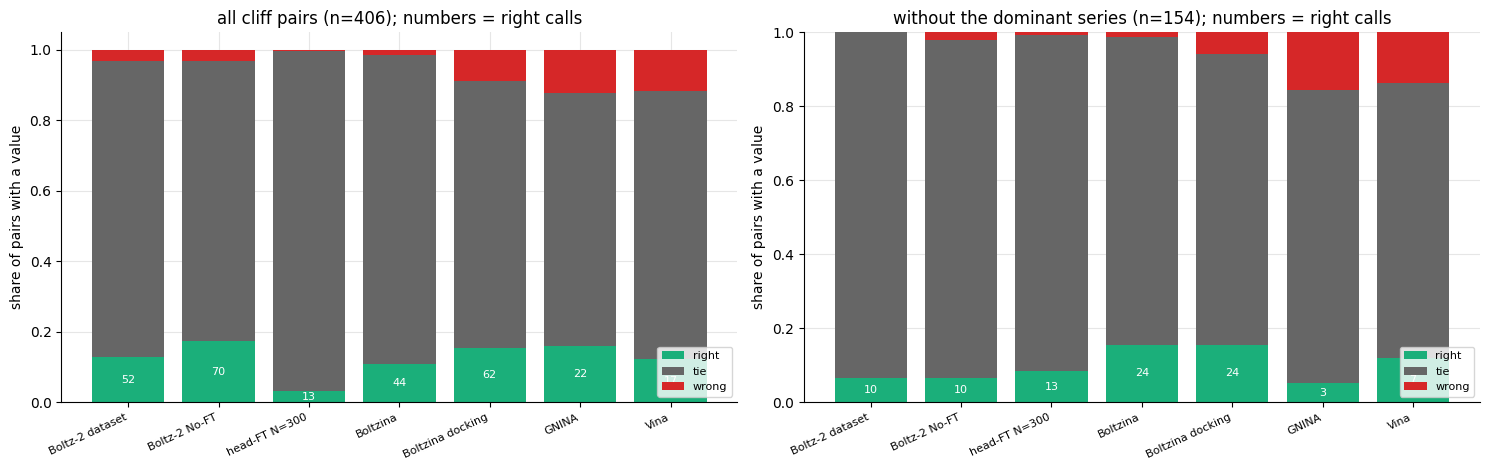

,right calls,wrong calls,distinct actives (right),distinct inactive partners (right),distinct series (right),right in dominant series,right outside it
modality,,,,,,,
Boltz-2 dataset,52,13,20,21,11,42,10
Boltz-2 No-FT,70,13,22,25,10,60,10
head-FT N=300,13,1,12,13,12,0,13
Boltzina,44,6,28,24,16,20,24
Boltzina docking,62,36,25,33,16,38,24
GNINA,22,17,7,12,3,19,3
Vina,17,16,13,10,6,10,7


In [2]:
MM=[("score_boltz2","Boltz-2 dataset"),("base_noft","Boltz-2 No-FT"),("ft300","head-FT N=300"),("score_boltzina","Boltzina"),("docking_score_boltzina","Boltzina docking"),("score_gnina","GNINA"),("score_vina","Vina")]
fig,axes=plt.subplots(1,2,figsize=(15,4.8))
for ax,(nm,d) in zip(axes,[("all cliff pairs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big])]):
    cnt=pd.DataFrame({l:d["o_"+m].value_counts() for m,l in MM}).reindex(["right","tie","wrong"]).fillna(0)
    frac=cnt/cnt.sum(); bottom=np.zeros(len(MM))
    for o in ["right","tie","wrong"]:
        ax.bar(range(len(MM)),frac.loc[o],bottom=bottom,color=OC[o],label=o); bottom+=frac.loc[o].values
    for i,(m,l) in enumerate(MM): ax.text(i,frac.loc["right"].iloc[i]/2,int(cnt.loc["right"].iloc[i]),ha="center",va="center",fontsize=8,color="white")
    ax.set_xticks(range(len(MM))); ax.set_xticklabels([l for _,l in MM],rotation=25,ha="right",fontsize=8); ax.set_ylabel("share of pairs with a value")
    ax.set_title(f"{nm} (n={len(d)}); numbers = right calls"); ax.legend(fontsize=8,loc="lower right")
plt.tight_layout(); plt.show()
rows=[]
for m,l in MM:
    R=CLIFF[CLIFF["o_"+m]=="right"]; W=CLIFF[CLIFF["o_"+m]=="wrong"]
    rows.append((l,len(R),len(W),R.id_a.nunique(),R.id_b.nunique(),R.series.nunique(),int(R.big.sum()),int((~R.big).sum())))
display(pd.DataFrame(rows,columns=["modality","right calls","wrong calls","distinct actives (right)","distinct inactive partners (right)","distinct series (right)","right in dominant series","right outside it"]).set_index("modality"))

**Sensitivity to the threshold.** The 0.3 cut-off is arbitrary. The same census at other cut-offs, for the Boltz-2 affinity head, to see whether the picture (few calls, few actives and partners, mostly one series) depends on it.

In [3]:
mx_=CLIFF[["d_score_boltz2","d_base_noft"]].max(axis=1); mn_=CLIFF[["d_score_boltz2","d_base_noft"]].min(axis=1); rows=[]
for th in (0.2,0.3,0.4,0.5):
    right=(mx_>th)&(mn_>-th); wrong=(mn_<-th)&(mx_<th); R_=CLIFF[right]
    rows.append((th,int(right.sum()),int(wrong.sum()),R_.id_a.nunique(),R_.id_b.nunique(),R_.series.nunique(),round(100*R_.big.mean(),0) if len(R_) else np.nan,int((~R_.big).sum())))
display(pd.DataFrame(rows,columns=["delta threshold","right calls","wrong calls","distinct actives (right)","distinct inactive partners (right)","distinct series (right)","% of right calls in the dominant series","right calls outside it"]).set_index("delta threshold"))

,right calls,wrong calls,distinct actives (right),distinct inactive partners (right),distinct series (right),% of right calls in the dominant series,right calls outside it
delta threshold,,,,,,,
0.2,137,56,40,48,21,81.0,26
0.3,91,24,27,30,13,86.0,13
0.4,39,3,19,16,7,82.0,7
0.5,18,1,11,9,5,78.0,4


## 2. Do the modalities get the same pairs right?
Overlap of the right-call sets. If different methods were reading the same real signal they would agree on which pairs are separable; if each catches its own set, the calls are more likely idiosyncratic.

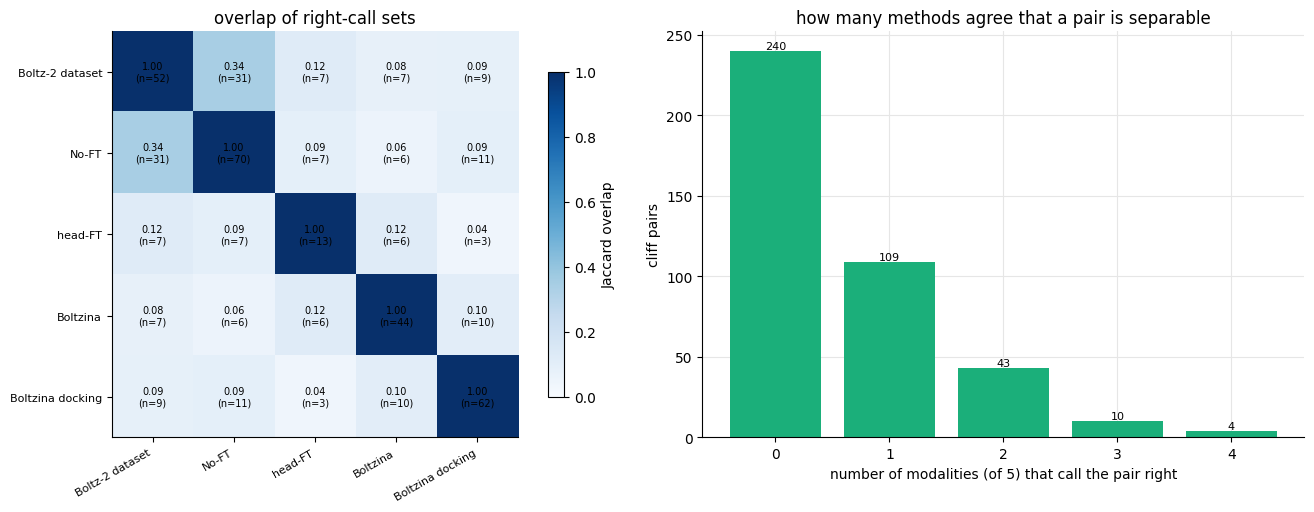

pairs called right by at least 3 of 5 modalities: 14 | by all 5: 0
observed overlap of right-call sets against the overlap expected if the two methods were independent:


,right (A),right (B),observed overlap,expected by chance,p (more overlap than chance)
pair of modalities,,,,,
Boltz-2 dataset & No-FT,52,70,31,9.0,0.0000
Boltz-2 dataset & head-FT,52,13,7,1.7,0.0004
Boltz-2 dataset & Boltzina,52,44,7,5.6,0.3259
Boltz-2 dataset & Boltzina docking,52,62,9,7.9,0.3957
No-FT & head-FT,70,13,7,2.2,0.0025
No-FT & Boltzina,70,44,6,7.6,0.8088
No-FT & Boltzina docking,70,62,11,10.7,0.5164
head-FT & Boltzina,13,44,6,1.4,0.0011
head-FT & Boltzina docking,13,62,3,2.0,0.3175


In [4]:
keys=[("score_boltz2","Boltz-2 dataset"),("base_noft","No-FT"),("ft300","head-FT"),("score_boltzina","Boltzina"),("docking_score_boltzina","Boltzina docking")]
sets={l:set(CLIFF.index[CLIFF["o_"+m]=="right"]) for m,l in keys}
J=np.array([[len(sets[a]&sets[b])/max(1,len(sets[a]|sets[b])) for _,b in keys] for _,a in keys])
N=np.array([[len(sets[a]&sets[b]) for _,b in keys] for _,a in keys])
fig,axes=plt.subplots(1,2,figsize=(14,5.2))
im=axes[0].imshow(J,cmap="Blues",vmin=0,vmax=1); axes[0].grid(False)
axes[0].set_xticks(range(len(keys))); axes[0].set_xticklabels([l for _,l in keys],rotation=30,ha="right",fontsize=8); axes[0].set_yticks(range(len(keys))); axes[0].set_yticklabels([l for _,l in keys],fontsize=8)
for i in range(len(keys)):
    for j in range(len(keys)): axes[0].text(j,i,f"{J[i,j]:.2f}\n(n={N[i,j]})",ha="center",va="center",fontsize=7)
fig.colorbar(im,ax=axes[0],shrink=0.8,label="Jaccard overlap"); axes[0].set_title("overlap of right-call sets")
nright=sum((CLIFF["o_"+m]=="right").astype(int) for m,_ in keys)
vc=nright.value_counts().sort_index(); axes[1].bar(vc.index,vc.values,color=GRN)
for x,y in zip(vc.index,vc.values): axes[1].text(x,y,int(y),ha="center",va="bottom",fontsize=8)
axes[1].set_xlabel("number of modalities (of 5) that call the pair right"); axes[1].set_ylabel("cliff pairs"); axes[1].set_title("how many methods agree that a pair is separable")
plt.tight_layout(); plt.show()
print("pairs called right by at least 3 of 5 modalities:",int((nright>=3).sum()),"| by all 5:",int((nright==5).sum()))
from scipy.stats import hypergeom
rows=[]; n_=len(CLIFF)
for i,(_,a) in enumerate(keys):
    for j,(_,b) in enumerate(keys):
        if i<j:
            A,B=sets[a],sets[b]; obs=len(A&B); exp=len(A)*len(B)/n_; rows.append((f"{a} & {b}",len(A),len(B),obs,round(exp,1),hypergeom.sf(obs-1,n_,len(A),len(B))))
print("observed overlap of right-call sets against the overlap expected if the two methods were independent:")
display(pd.DataFrame(rows,columns=["pair of modalities","right (A)","right (B)","observed overlap","expected by chance","p (more overlap than chance)"]).set_index("pair of modalities").round(4))


## 3. The strongest correct calls, drawn
Pairs where the Boltz-2 affinity head is right, ranked by how large the delta is (ties in delta broken by pair similarity). The differing atoms are highlighted; the legend gives percentiles for Boltz-2 dataset, No-FT, Boltzina and docking (active first, inactive second).

similarity range of these pairs: 0.60 to 0.66
Strongest correct calls by the Boltz-2 affinity head (largest positive delta), one row per inactive partner


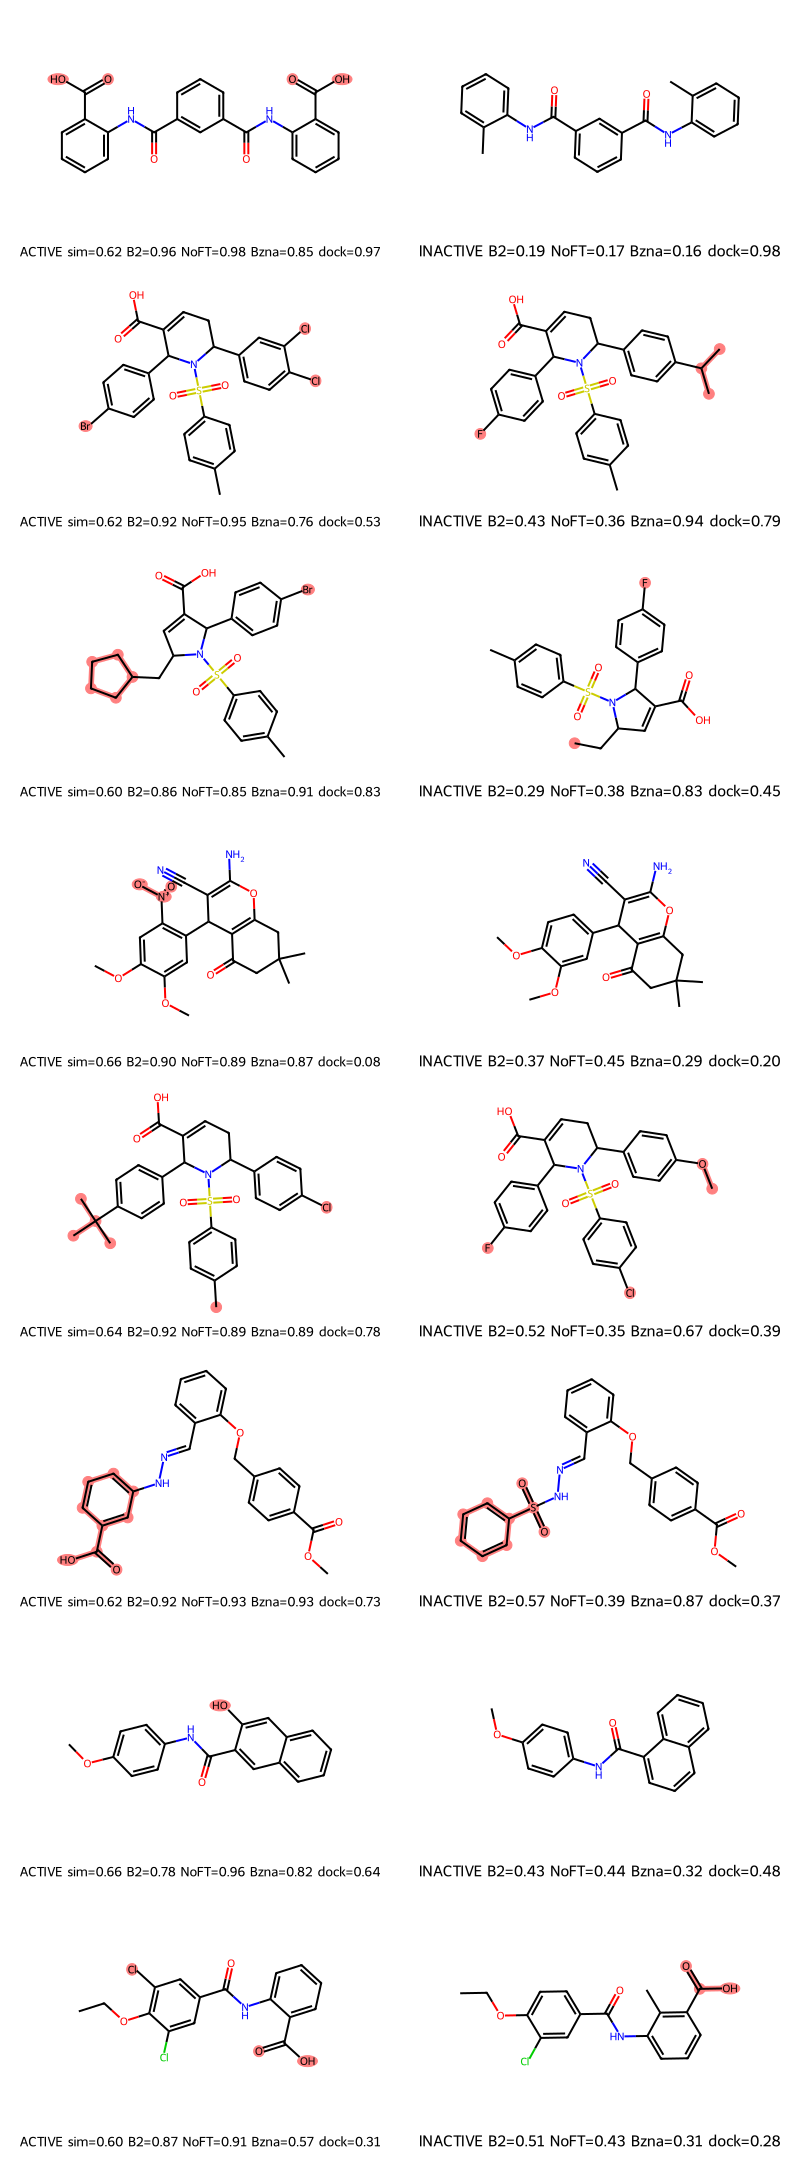

In [5]:
CLIFF["b2_delta"]=CLIFF[["d_score_boltz2","d_base_noft"]].mean(axis=1)
top=CLIFF[(CLIFF.o_b2=="right")&(CLIFF.mcs_ok==1)].sort_values(["b2_delta","sim"],ascending=False).drop_duplicates("id_b")
print("similarity range of these pairs: %.2f to %.2f"%(top.head(8).sim.min(),top.head(8).sim.max()))
draw_pairs2(top,8,"Strongest correct calls by the Boltz-2 affinity head (largest positive delta), one row per inactive partner")

## 3b. How similar are the correct calls, and how independent are they?
Ranking pairs by delta size favours the least similar pairs, so the gallery above is not a fair picture of the near-identical cases. Here the outcome by similarity bin, the reuse of inactive partners (one inactive compound paired with several actives is one observation, not several), and a gallery restricted to the most similar pairs.

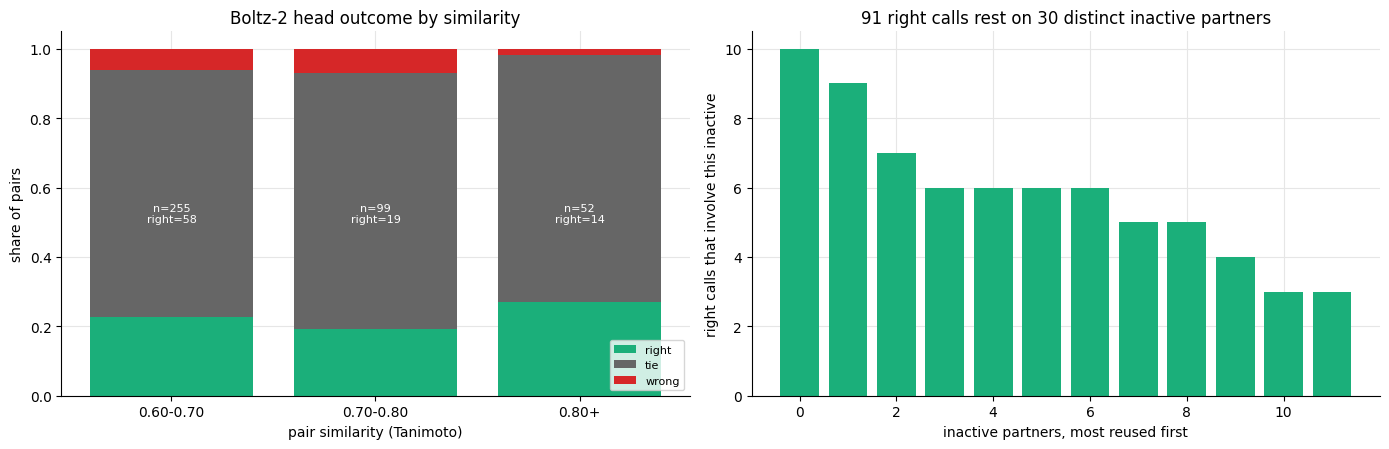

right calls 91; distinct inactive partners 30; distinct actives 27; the 3 most reused partners account for 26 calls
right calls at similarity >= 0.8: 14 | wrong calls at >= 0.8: 1


In [6]:
CLIFF["sb"]=pd.cut(CLIFF.sim,[0.6,0.7,0.8,1.01],right=False,labels=["0.60-0.70","0.70-0.80","0.80+"])
ct=pd.crosstab(CLIFF.sb,CLIFF.o_b2).reindex(columns=["right","tie","wrong"]); fr=ct.div(ct.sum(1),axis=0)
R=CLIFF[CLIFF.o_b2=="right"]; pc=R.id_b.value_counts()
fig,axes=plt.subplots(1,2,figsize=(14,4.6)); bottom=np.zeros(len(fr))
for o in ["right","tie","wrong"]:
    axes[0].bar(range(len(fr)),fr[o],bottom=bottom,color=OC[o],label=o); bottom+=fr[o].values
for i,(b_,r_) in enumerate(ct.iterrows()): axes[0].text(i,0.5,f"n={int(r_.sum())}\nright={int(r_['right'])}",ha="center",fontsize=8,color="white")
axes[0].set_xticks(range(len(fr))); axes[0].set_xticklabels(fr.index); axes[0].set_xlabel("pair similarity (Tanimoto)"); axes[0].set_ylabel("share of pairs"); axes[0].legend(fontsize=8,loc="lower right"); axes[0].set_title("Boltz-2 head outcome by similarity")
axes[1].bar(range(min(12,len(pc))),pc.values[:12],color=GRN); axes[1].set_xlabel("inactive partners, most reused first"); axes[1].set_ylabel("right calls that involve this inactive"); axes[1].set_title(f"{len(R)} right calls rest on {R.id_b.nunique()} distinct inactive partners")
plt.tight_layout(); plt.show()
print(f"right calls {len(R)}; distinct inactive partners {R.id_b.nunique()}; distinct actives {R.id_a.nunique()}; the 3 most reused partners account for {int(pc.head(3).sum())} calls")
print("right calls at similarity >= 0.8:",int((R.sim>=0.8).sum()),"| wrong calls at >= 0.8:",int(((CLIFF.o_b2=="wrong")&(CLIFF.sim>=0.8)).sum()))

Correct calls among the most identical pairs (Tanimoto >= 0.8), one per active and per inactive partner


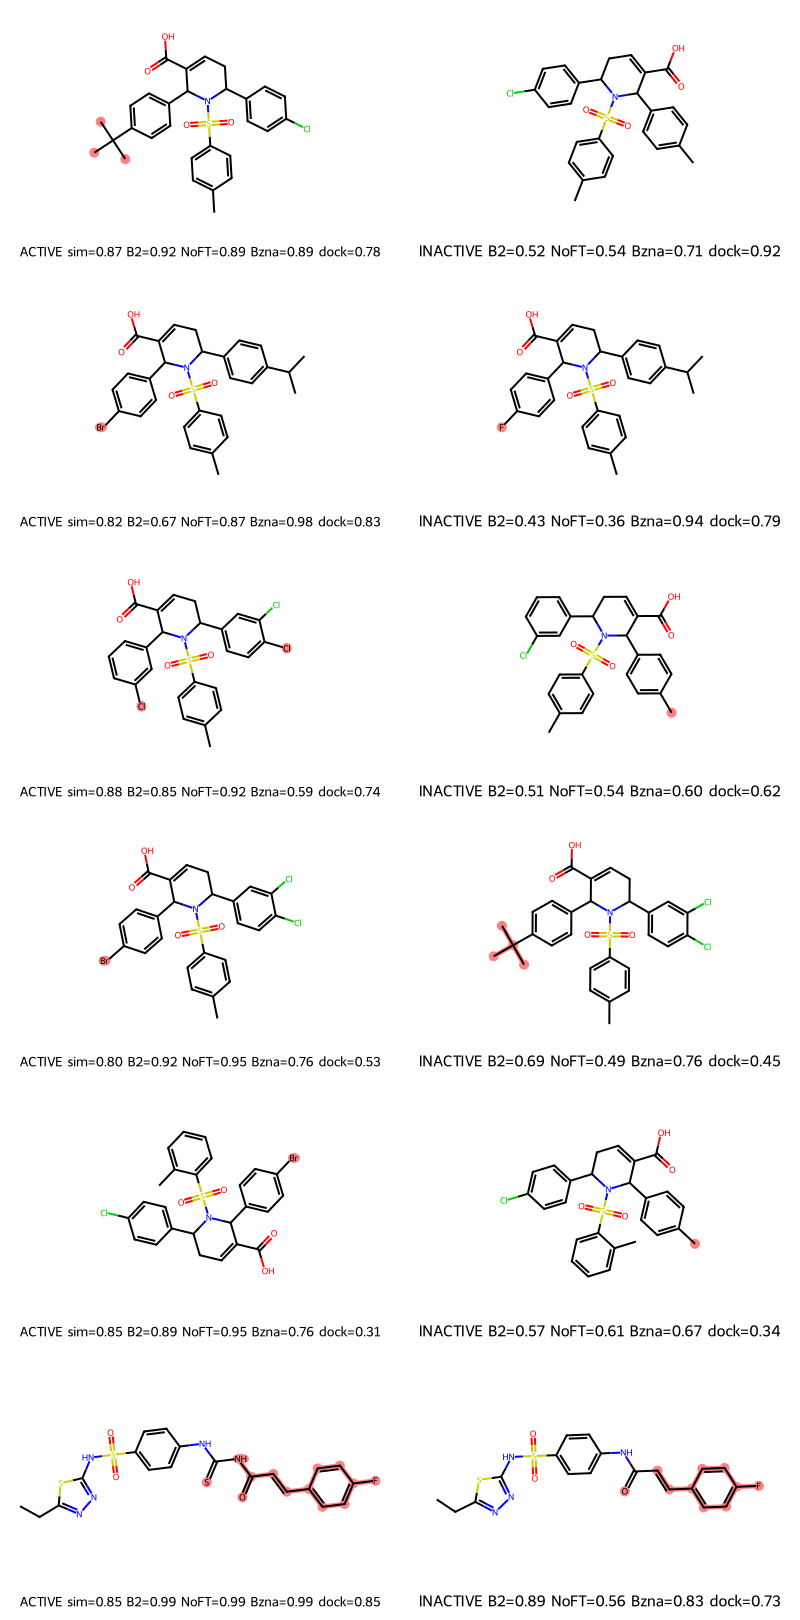

In [7]:
hi=CLIFF[(CLIFF.o_b2=="right")&(CLIFF.sim>=0.8)&(CLIFF.mcs_ok==1)].sort_values("b2_delta",ascending=False).drop_duplicates("id_a").drop_duplicates("id_b")
draw_pairs2(hi,8,"Correct calls among the most identical pairs (Tanimoto >= 0.8), one per active and per inactive partner")

## 4. Is it just size and lipophilicity?
For pairs the Boltz-2 head gets right, ties on, or gets wrong: the size and lipophilicity difference between active and inactive. If the correct calls are simply the pairs where the active is larger or greasier, the right box will sit clearly above zero and the wrong box below.

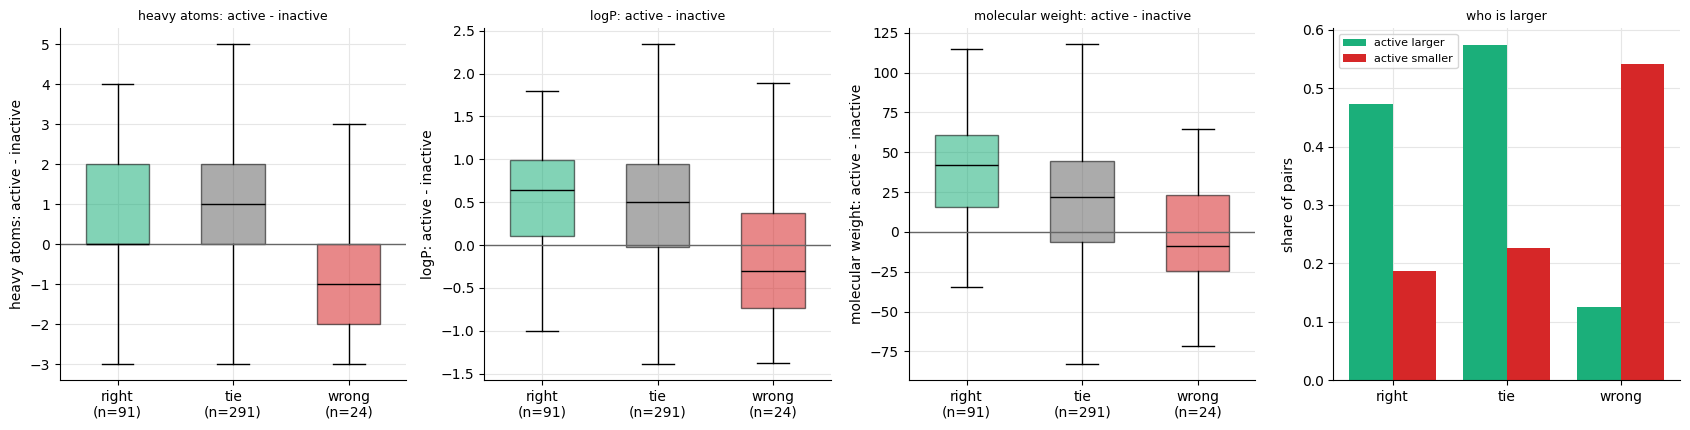

heavy atoms  median (active-inactive): right +0.00 | tie +1.00 | right vs tie Mann-Whitney p=0.43
logP         median (active-inactive): right +0.64 | tie +0.50 | right vs tie Mann-Whitney p=0.33
MW           median (active-inactive): right +42.08 | tie +21.66 | right vs tie Mann-Whitney p=0.00016


In [8]:
grp=["right","tie","wrong"]; fig,axes=plt.subplots(1,4,figsize=(17,4.4))
for ax,(c,l) in zip(axes[:3],[("dp_heavy","heavy atoms: active - inactive"),("dp_logP","logP: active - inactive"),("dp_MW","molecular weight: active - inactive")]):
    boxes(ax,[CLIFF[CLIFF.o_b2==g][c].dropna() for g in grp],[f"{g}\n(n={int((CLIFF.o_b2==g).sum())})" for g in grp],[OC[g] for g in grp],l,l)
share=[(CLIFF[CLIFF.o_b2==g].dp_heavy>0).mean() for g in grp]; sm=[(CLIFF[CLIFF.o_b2==g].dp_heavy<0).mean() for g in grp]
x=np.arange(3); axes[3].bar(x-0.19,share,0.38,color=GRN,label="active larger"); axes[3].bar(x+0.19,sm,0.38,color=CL,label="active smaller")
axes[3].set_xticks(x); axes[3].set_xticklabels(grp); axes[3].set_ylabel("share of pairs"); axes[3].legend(fontsize=8); axes[3].set_title("who is larger",fontsize=9)
plt.tight_layout(); plt.show()
for c,l in [("dp_heavy","heavy atoms"),("dp_logP","logP"),("dp_MW","MW")]:
    a=CLIFF[CLIFF.o_b2=="right"][c].dropna(); b=CLIFF[CLIFF.o_b2=="tie"][c].dropna()
    print(f"{l:<12} median (active-inactive): right {a.median():+.2f} | tie {b.median():+.2f} | right vs tie Mann-Whitney p={stats.mannwhitneyu(a,b).pvalue:.2g}")

## 5. Does the size of the delta scale with the size of the property difference?
If the head were reading lipophilicity or mass, a bigger property difference should give a bigger score delta across all cliff pairs, not just the ones called right.

Boltz-2 dataset vs logP difference: Spearman all pairs rho=0.19 (p=0.00014); other series only rho=-0.10 (p=0.21, n=154)
No-FT vs logP difference: Spearman all pairs rho=0.13 (p=0.0095); other series only rho=-0.10 (p=0.2, n=154)
Boltz-2 dataset vs MW difference: Spearman all pairs rho=0.30 (p=7e-10); other series only rho=0.04 (p=0.61, n=154)


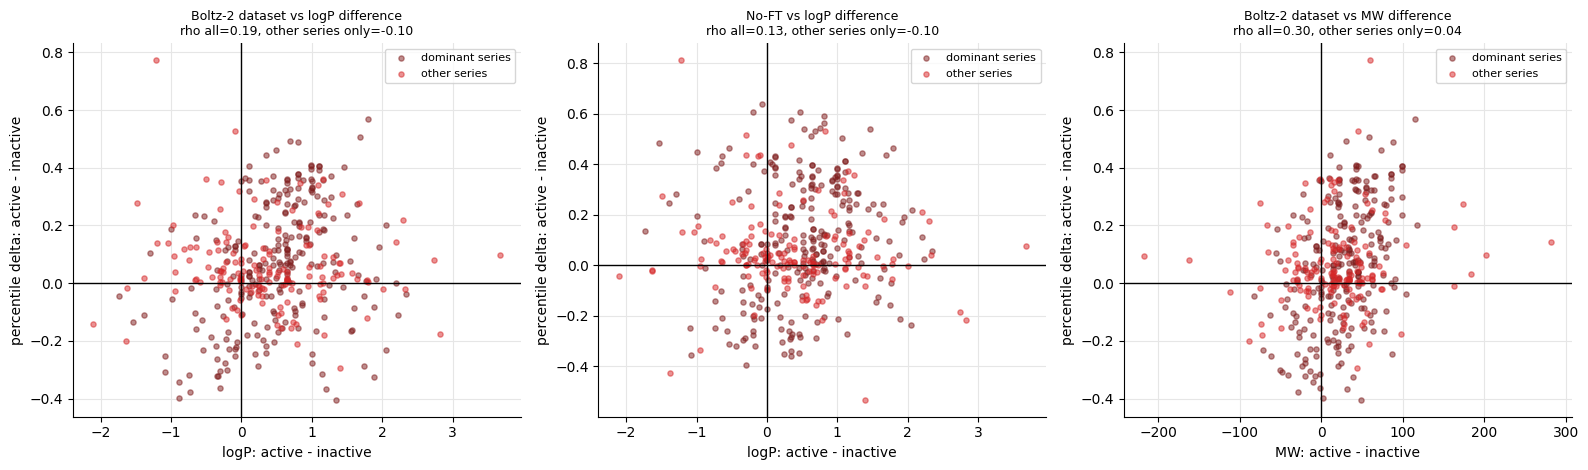

In [9]:
fig,axes=plt.subplots(1,3,figsize=(16,4.8)); cmap={True:"#7f1d1d",False:CL}
for ax,(dcol,pcol,l) in zip(axes,[("d_score_boltz2","dp_logP","Boltz-2 dataset vs logP difference"),("d_base_noft","dp_logP","No-FT vs logP difference"),("d_score_boltz2","dp_MW","Boltz-2 dataset vs MW difference")]):
    d=CLIFF[[dcol,pcol,"big"]].dropna()
    for b_,c in cmap.items():
        s=d[d.big==b_]; ax.scatter(s[pcol],s[dcol],s=14,alpha=0.5,color=c,label="dominant series" if b_ else "other series")
    r,p=stats.spearmanr(d[pcol],d[dcol]); r2,p2=stats.spearmanr(d[~d.big][pcol],d[~d.big][dcol])
    ax.axhline(0,color=BLK,lw=1); ax.axvline(0,color=BLK,lw=1); ax.set_xlabel(pcol.replace("dp_","")+": active - inactive"); ax.set_ylabel("percentile delta: active - inactive")
    ax.set_title(f"{l}\nrho all={r:.2f}, other series only={r2:.2f}",fontsize=9); ax.legend(fontsize=8); print(f"{l}: Spearman all pairs rho={r:.2f} (p={p:.2g}); other series only rho={r2:.2f} (p={p2:.2g}, n={len(d[~d.big])})")
plt.tight_layout(); plt.show()

## 6. The non-trivial correct calls
Restrict to pairs where the trivial explanation is unavailable: the active is **not larger** and **not more lipophilic** than the inactive (heavy-atom difference <= 0 and logP difference <= 0.1). Here a right call cannot be a size or greasiness effect. Counts of right and wrong calls per modality, then the right calls drawn.

,right,wrong,pairs with a value,distinct actives (right),distinct series (right)
modality,,,,,
Boltz-2 dataset,2,9,85,2,1
Boltz-2 No-FT,12,5,85,9,2
head-FT N=300,2,1,85,2,2
Boltzina,8,1,85,8,5
Boltzina docking,5,16,85,5,2
GNINA,3,4,29,2,1
Vina,2,5,29,2,2


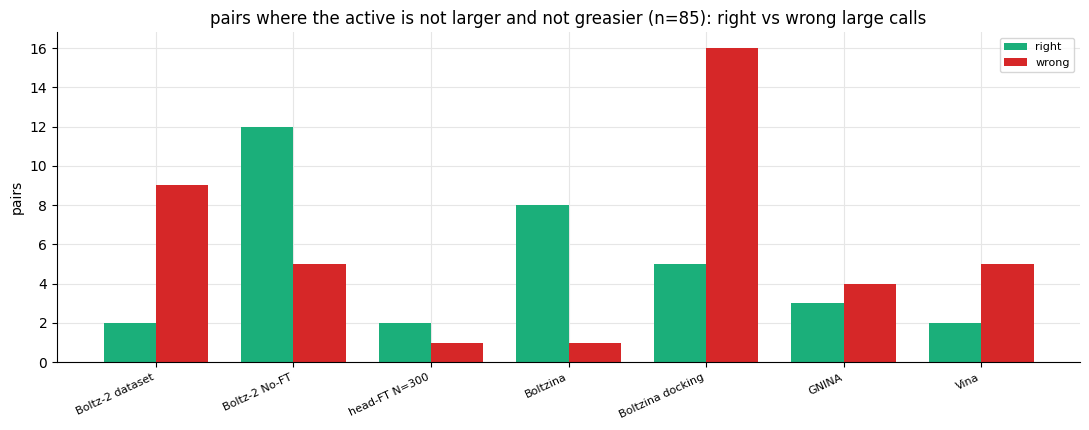

Non-trivial correct calls (No-FT or Boltzina), one per active


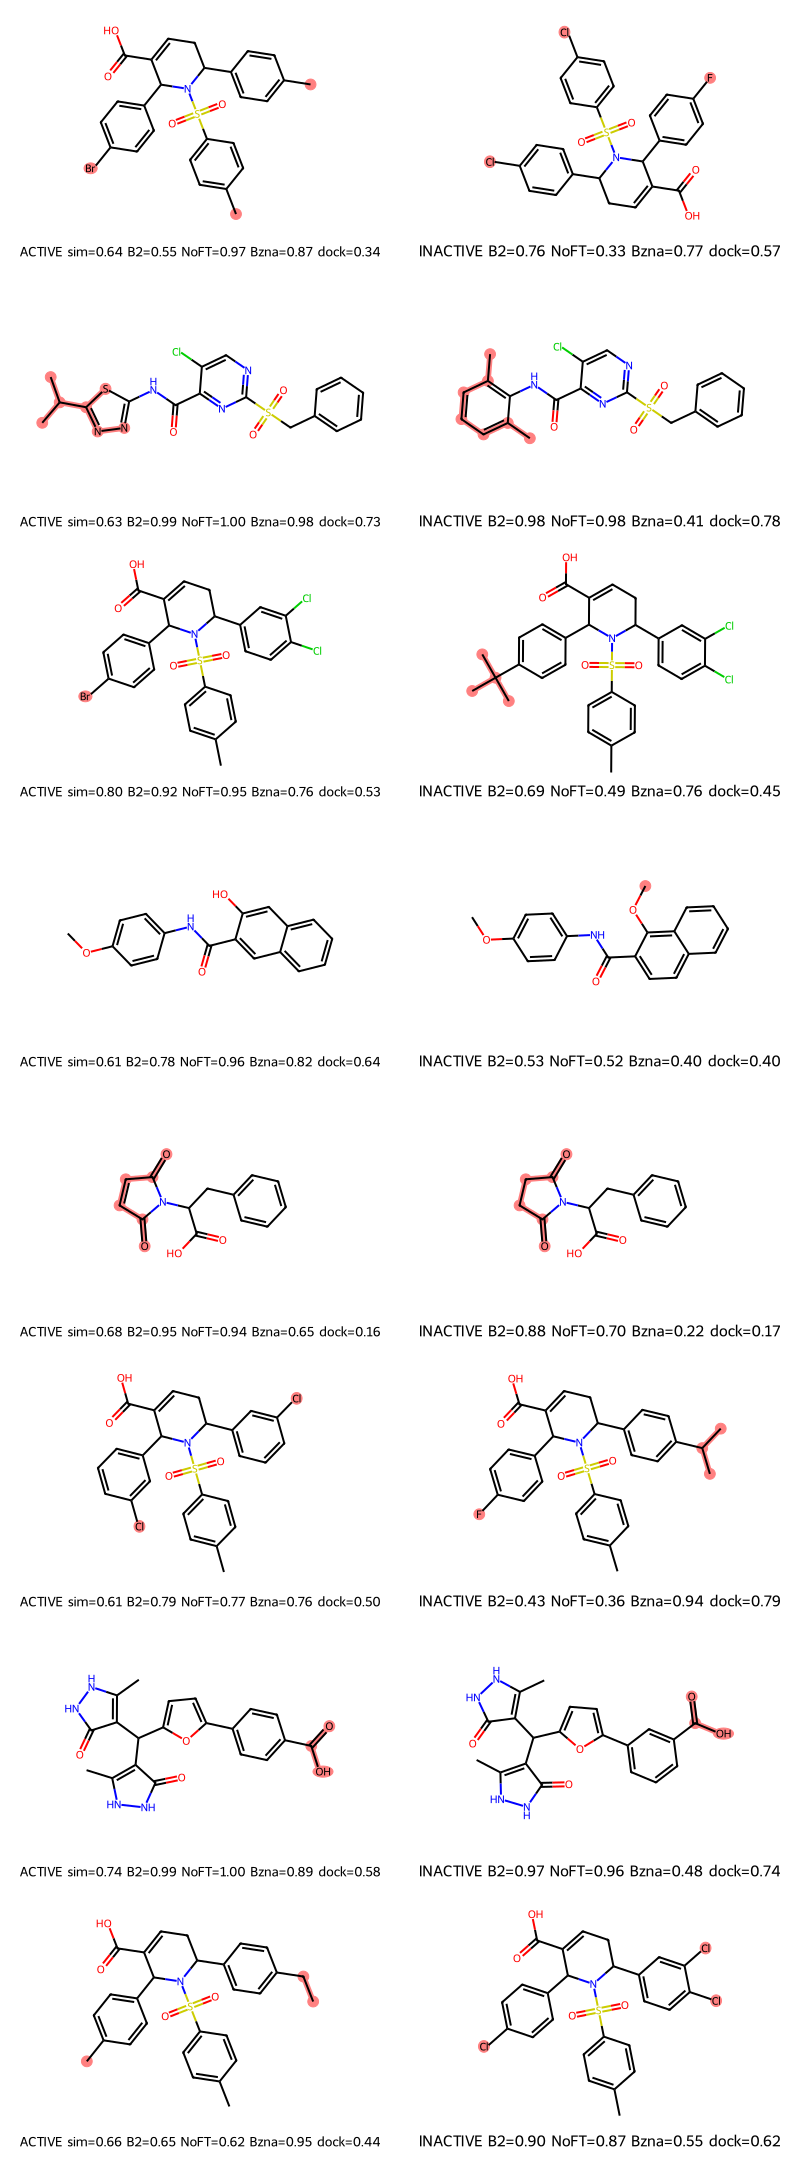

In [10]:
NT=CLIFF[(CLIFF.dp_heavy<=0)&(CLIFF.dp_logP<=0.1)].copy()
rows=[]
for m,l in MM:
    d=NT["o_"+m].dropna(); R=NT[NT["o_"+m]=="right"]
    rows.append((l,int((d=="right").sum()),int((d=="wrong").sum()),len(d),R.id_a.nunique(),R.series.nunique()))
T6=pd.DataFrame(rows,columns=["modality","right","wrong","pairs with a value","distinct actives (right)","distinct series (right)"]).set_index("modality")
display(T6)
fig,ax=plt.subplots(figsize=(11,4.4)); x=np.arange(len(T6)); ax.bar(x-0.19,T6.right,0.38,color=GRN,label="right"); ax.bar(x+0.19,T6.wrong,0.38,color=CL,label="wrong")
ax.set_xticks(x); ax.set_xticklabels(T6.index,rotation=25,ha="right",fontsize=8); ax.set_ylabel("pairs"); ax.legend(fontsize=8)
ax.set_title(f"pairs where the active is not larger and not greasier (n={len(NT)}): right vs wrong large calls"); plt.tight_layout(); plt.show()
NT["nt_delta"]=NT[["d_base_noft","d_score_boltzina"]].max(axis=1)
draw_pairs2(NT[(NT.mcs_ok==1)&((NT.o_base_noft=="right")|(NT.o_score_boltzina=="right"))].sort_values("nt_delta",ascending=False).drop_duplicates("id_a").drop_duplicates("id_b"),8,"Non-trivial correct calls (No-FT or Boltzina), one per active")

## 7. Which edits are separated correctly?
The recurring transformations, written as the fragment the active has followed by the fragment the inactive has, with the share of pairs the Boltz-2 head calls right, ties, or gets wrong. Only transformations seen at least 4 times.

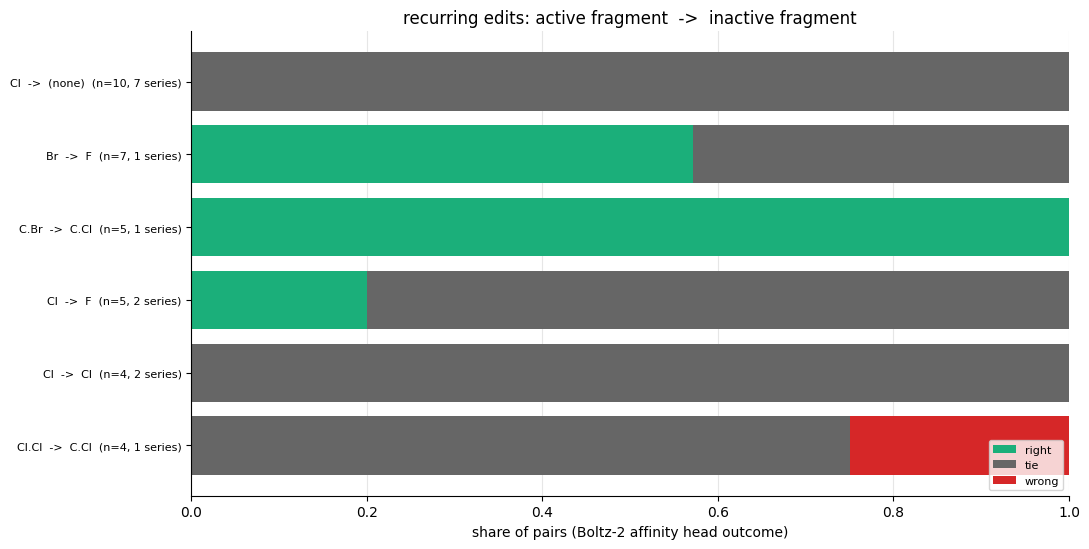

,n,right,wrong,tie,series,dominant_share
edit,,,,,,
Cl -> (none),10,0.00,0.00,1.00,7,0.40
Br -> F,7,0.57,0.00,0.43,1,1.00
C.Br -> C.Cl,5,1.00,0.00,0.00,1,1.00
Cl -> F,5,0.20,0.00,0.80,2,0.80
Cl -> Cl,4,0.00,0.00,1.00,2,0.75
Cl.Cl -> C.Cl,4,0.00,0.25,0.75,1,1.00


In [11]:
C=CLIFF[CLIFF.mcs_ok==1].copy()
C["edit"]=C.a_diff_smi.fillna("").replace("","(none)")+"  ->  "+C.b_diff_smi.fillna("").replace("","(none)")
g=C.groupby("edit"); tab=pd.DataFrame({"n":g.size(),"right":g.apply(lambda d:(d.o_b2=="right").mean()),"wrong":g.apply(lambda d:(d.o_b2=="wrong").mean()),"tie":g.apply(lambda d:(d.o_b2=="tie").mean()),
                                        "series":g.series.nunique(),"dominant_share":g.apply(lambda d:d.big.mean())})
tab=tab[tab.n>=4].sort_values("n",ascending=False).head(14)
fig,ax=plt.subplots(figsize=(11,5.6)); y=np.arange(len(tab))[::-1]; left=np.zeros(len(tab))
for o in ["right","tie","wrong"]:
    ax.barh(y,tab[o],left=left,color=OC[o],label=o); left+=tab[o].values
ax.set_yticks(y); ax.set_yticklabels([f"{e}  (n={int(n)}, {int(s)} series)" for e,n,s in zip(tab.index,tab.n,tab.series)],fontsize=8)
ax.set_xlabel("share of pairs (Boltz-2 affinity head outcome)"); ax.legend(fontsize=8,loc="lower right"); ax.set_title("recurring edits: active fragment  ->  inactive fragment")
plt.tight_layout(); plt.show(); display(tab.round(2))

share of right calls  \
subset                                              all cliffs   
edit property                                                    
fragment size differs by 3+ atoms                        0.275   
inactive is less lipophilic (>= 0.5 logP)                0.582   
inactive is lighter (>= 20 Da)                           0.714   
inactive is smaller (>= 1 heavy atom)                    0.473   
polar atoms / H-bond donors change                       0.187   
same molecular formula (regioisomer)                     0.011   
single-atom swap                                         0.121   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               0.385   
inactive is less lipophilic (>= 0.5 logP)                       0.385   
inactive is lighter (>= 20 Da)                                  0.462   
inactive is smaller (>= 1 heavy atom)                           0.615   
polar atoms / H-bond donors change                              0.769   
same molecular formula (regioisomer)                            0.000   
single-atom swap                                                0.231   

                                          share of tie calls  \
subset                                            all cliffs   
edit property                                                  
fragment size differs by 3+ atoms                      0.271   
inactive is less lipophilic (>= 0.5 logP)              0.502   
inactive is lighter (>= 20 Da)                         0.533   
inactive is smaller (>= 1 heavy atom)                  0.574   
polar atoms / H-bond donors change                     0.316   
same molecular formula (regioisomer)                   0.027   
single-atom swap                                       0.137   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               0.391   
inactive is less lipophilic (>= 0.5 logP)                       0.449   
inactive is lighter (>= 20 Da)                                  0.464   
inactive is smaller (>= 1 heavy atom)                           0.609   
polar atoms / H-bond donors change                              0.500   
same molecular formula (regioisomer)                            0.022   
single-atom swap                                                0.116   

                                          odds ratio  \
subset                                    all cliffs   
edit property                                          
fragment size differs by 3+ atoms              1.016   
inactive is less lipophilic (>= 0.5 logP)      1.385   
inactive is lighter (>= 20 Da)                 2.194   
inactive is smaller (>= 1 heavy atom)          0.665   
polar atoms / H-bond donors change             0.497   
same molecular formula (regioisomer)           0.393   
single-atom swap                               0.863   

                                                                       \
subset                                    without the dominant series   
edit property                                                           
fragment size differs by 3+ atoms                               0.972   
inactive is less lipophilic (>= 0.5 logP)                       0.766   
inactive is lighter (>= 20 Da)                                  0.991   
inactive is smaller (>= 1 heavy atom)                           1.029   
polar atoms / H-bond donors change                              3.333   
same molecular formula (regioisomer)                            0.000   
single-atom swap                                            

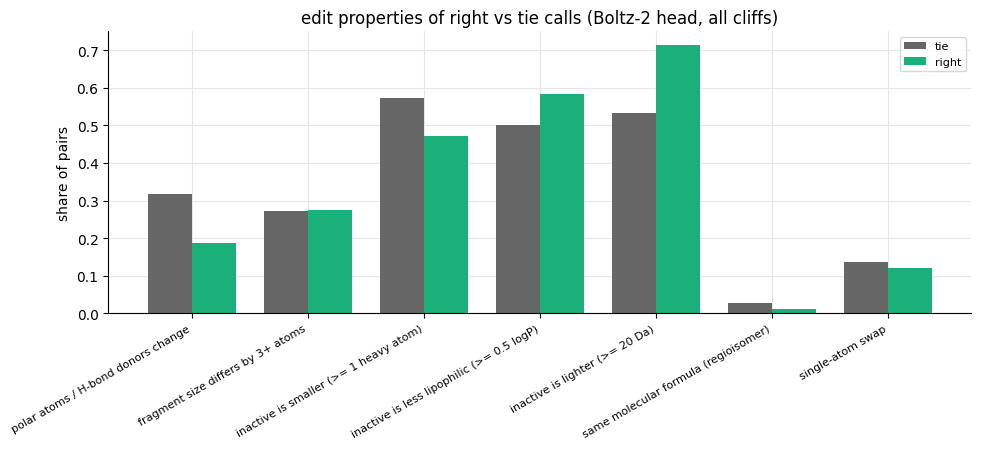

In [12]:
def flag_table(df):
    f=pd.DataFrame(index=df.index)
    f["polar atoms / H-bond donors change"]=(df.a_diff_hbd!=df.b_diff_hbd)|((df.a_diff_has_N+df.a_diff_has_O)!=(df.b_diff_has_N+df.b_diff_has_O))
    f["fragment size differs by 3+ atoms"]=(df.b_diff_n-df.a_diff_n).abs()>=3
    f["inactive is smaller (>= 1 heavy atom)"]=df.dp_heavy>=1
    f["inactive is less lipophilic (>= 0.5 logP)"]=df.dp_logP>=0.5
    f["inactive is lighter (>= 20 Da)"]=df.dp_MW>=20
    f["same molecular formula (regioisomer)"]=df.dp_MW.abs()<0.01
    f["single-atom swap"]=(df.a_diff_n<=1)&(df.b_diff_n<=1)
    return f
rows=[]
for nm,d in [("all cliffs",C),("without the dominant series",C[~C.big])]:
    F=flag_table(d); r_=d.o_b2=="right"; t_=d.o_b2=="tie"
    for c in F.columns:
        a=int((F[c]&r_).sum()); b=int((~F[c]&r_).sum()); e=int((F[c]&t_).sum()); f_=int((~F[c]&t_).sum())
        o,p=stats.fisher_exact([[a,b],[e,f_]]); rows.append((nm,c,F[c][r_].mean(),F[c][t_].mean(),o,p))
T7=pd.DataFrame(rows,columns=["subset","edit property","share of right calls","share of tie calls","odds ratio","Fisher p"])
display(T7.pivot(index="edit property",columns="subset",values=["share of right calls","share of tie calls","odds ratio","Fisher p"]).round(3))
fig,ax=plt.subplots(figsize=(10,4.6)); s7=T7[T7.subset=="all cliffs"].set_index("edit property"); x=np.arange(len(s7))
ax.bar(x-0.19,s7["share of tie calls"],0.38,color=NEU,label="tie"); ax.bar(x+0.19,s7["share of right calls"],0.38,color=GRN,label="right")
ax.set_xticks(x); ax.set_xticklabels(s7.index,rotation=30,ha="right",fontsize=8); ax.set_ylabel("share of pairs"); ax.legend(fontsize=8); ax.set_title("edit properties of right vs tie calls (Boltz-2 head, all cliffs)")
plt.tight_layout(); plt.show()

## 8. Did the two poses differ in the correct calls?
Contact-set dissimilarity between the active's and the inactive's poses, by outcome. If a correct call needs the models to place the two molecules differently, right calls should have more dissimilar poses than ties.

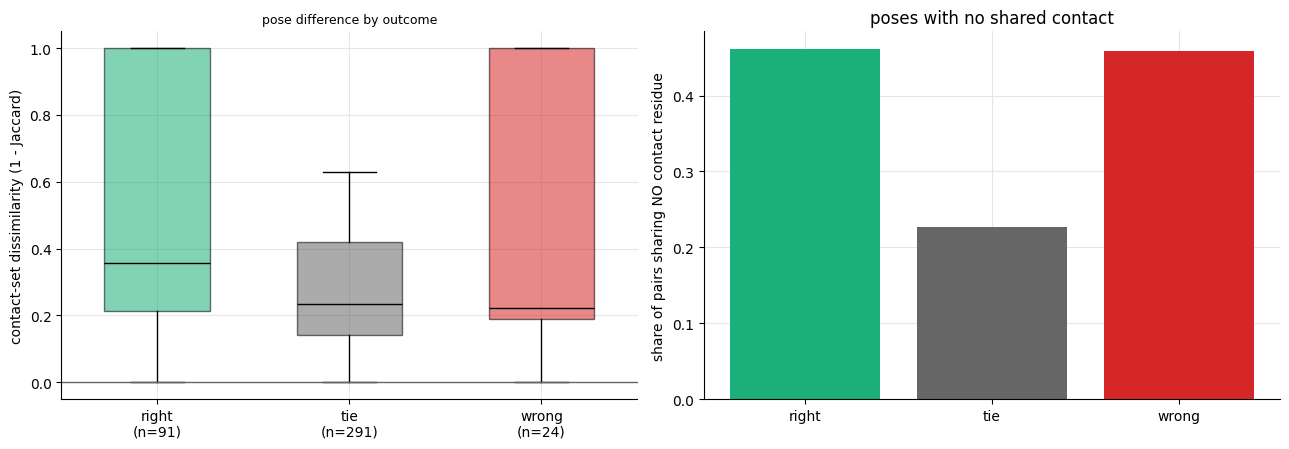

median contact dissimilarity by outcome: {'right': np.float64(0.36), 'tie': np.float64(0.24), 'wrong': np.float64(0.22)}
median dissimilarity: right 0.36 | tie 0.24 | Mann-Whitney p=7.4e-05
without the dominant series: right n=13 median 0.29 | tie n=138 median 0.21 | p=0.16


In [13]:
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
boxes(axes[0],[CLIFF[CLIFF.o_b2==g].pose_jdist.dropna() for g in grp],[f"{g}\n(n={int((CLIFF.o_b2==g).sum())})" for g in grp],[OC[g] for g in grp],"contact-set dissimilarity (1 - Jaccard)","pose difference by outcome")
axes[0].axhline(0,color=NEU,lw=0)
sh=[(CLIFF[CLIFF.o_b2==g].pose_jdist>=0.99).mean() for g in grp]; axes[1].bar(range(3),sh,color=[OC[g] for g in grp]); axes[1].set_xticks(range(3)); axes[1].set_xticklabels(grp)
axes[1].set_ylabel("share of pairs sharing NO contact residue"); axes[1].set_title("poses with no shared contact")
plt.tight_layout(); plt.show()
a=CLIFF[CLIFF.o_b2=="right"].pose_jdist.dropna(); b=CLIFF[CLIFF.o_b2=="tie"].pose_jdist.dropna()
print("median contact dissimilarity by outcome:", {g:round(CLIFF[CLIFF.o_b2==g].pose_jdist.median(),2) for g in grp})
print(f"median dissimilarity: right {a.median():.2f} | tie {b.median():.2f} | Mann-Whitney p={stats.mannwhitneyu(a,b).pvalue:.2g}")
for nm,d in [("without the dominant series",CLIFF[~CLIFF.big])]:
    a=d[d.o_b2=="right"].pose_jdist.dropna(); b=d[d.o_b2=="tie"].pose_jdist.dropna()
    print(f"{nm}: right n={len(a)} median {a.median():.2f} | tie n={len(b)} median {b.median():.2f} | p={stats.mannwhitneyu(a,b).pvalue:.2g}" if len(a)>3 else f"{nm}: only {len(a)} right calls")

## 8b. Are the correct calls recognising reactive or interference chemotypes?
Some right calls have an obvious chemical reason (a maleimide active against its saturated succinimide partner). If the head were largely picking up reactive or assay-interfering groups, right calls would be enriched in structural alerts. The dataset's own PAINS column is False for every compound (the library was already filtered), so alerts are computed here with RDKit's Brenk and PAINS catalogs.

,pairs,active has an alert,inactive partner has an alert
outcome,,,
right,91,0.05,0.03
tie,291,0.25,0.20
wrong,24,0.12,0.12


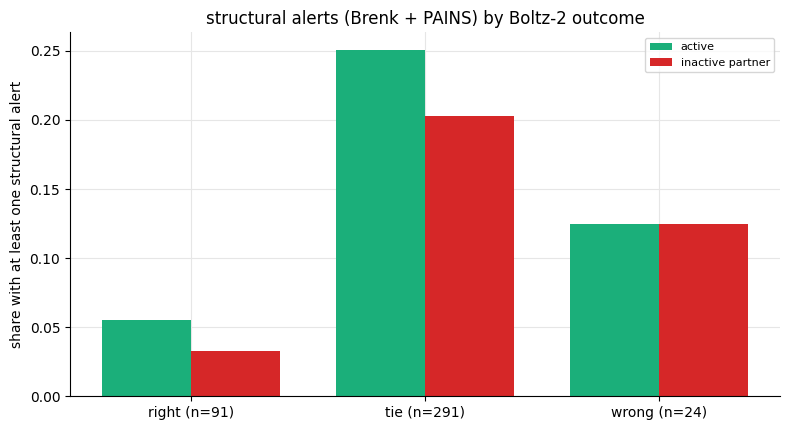

alerts carried by the actives of right calls: [('Michael_acceptor_1', 2), ('Oxygen-nitrogen_single_bond', 2), ('Thiocarbonyl_group', 1), ('nitro_group', 1), ('imine_1', 1), ('conjugated_nitrile_group', 1)]


In [14]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from collections import Counter
pr_=FilterCatalogParams(); pr_.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK); pr_.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS); fcat=FilterCatalog(pr_)
def alerts(smi):
    m=Chem.MolFromSmiles(smi); return [e.GetDescription() for e in fcat.GetMatches(m)] if m else []
mem=pd.unique(np.concatenate([CLIFF.id_a,CLIFF.id_b])); AL={i:alerts(Mi.smiles[i]) for i in mem}
CLIFF["alert_a"]=[len(AL[i])>0 for i in CLIFF.id_a]; CLIFF["alert_b"]=[len(AL[i])>0 for i in CLIFF.id_b]
rows=[(g,int((CLIFF.o_b2==g).sum()),CLIFF[CLIFF.o_b2==g].alert_a.mean(),CLIFF[CLIFF.o_b2==g].alert_b.mean()) for g in grp]
T=pd.DataFrame(rows,columns=["outcome","pairs","active has an alert","inactive partner has an alert"]).set_index("outcome"); display(T.round(2))
fig,ax=plt.subplots(figsize=(8,4.4)); x=np.arange(3); ax.bar(x-0.19,T["active has an alert"],0.38,color=GRN,label="active"); ax.bar(x+0.19,T["inactive partner has an alert"],0.38,color=CL,label="inactive partner")
ax.set_xticks(x); ax.set_xticklabels([f"{g} (n={int(T.loc[g,'pairs'])})" for g in grp]); ax.set_ylabel("share with at least one structural alert"); ax.legend(fontsize=8); ax.set_title("structural alerts (Brenk + PAINS) by Boltz-2 outcome")
plt.tight_layout(); plt.show()
print("alerts carried by the actives of right calls:",Counter(a for i in CLIFF[CLIFF.o_b2=="right"].id_a.unique() for a in AL[i]).most_common(6))

## 9. Where along the protein is the active closer than the inactive?
For every residue, the mean of (inactive's distance to the ligand minus active's distance to the ligand), so a positive value means the active sits closer to that residue than its inactive partner does. Shown for pairs the head calls right and for ties, along the full sequence, with the largest differences labelled.

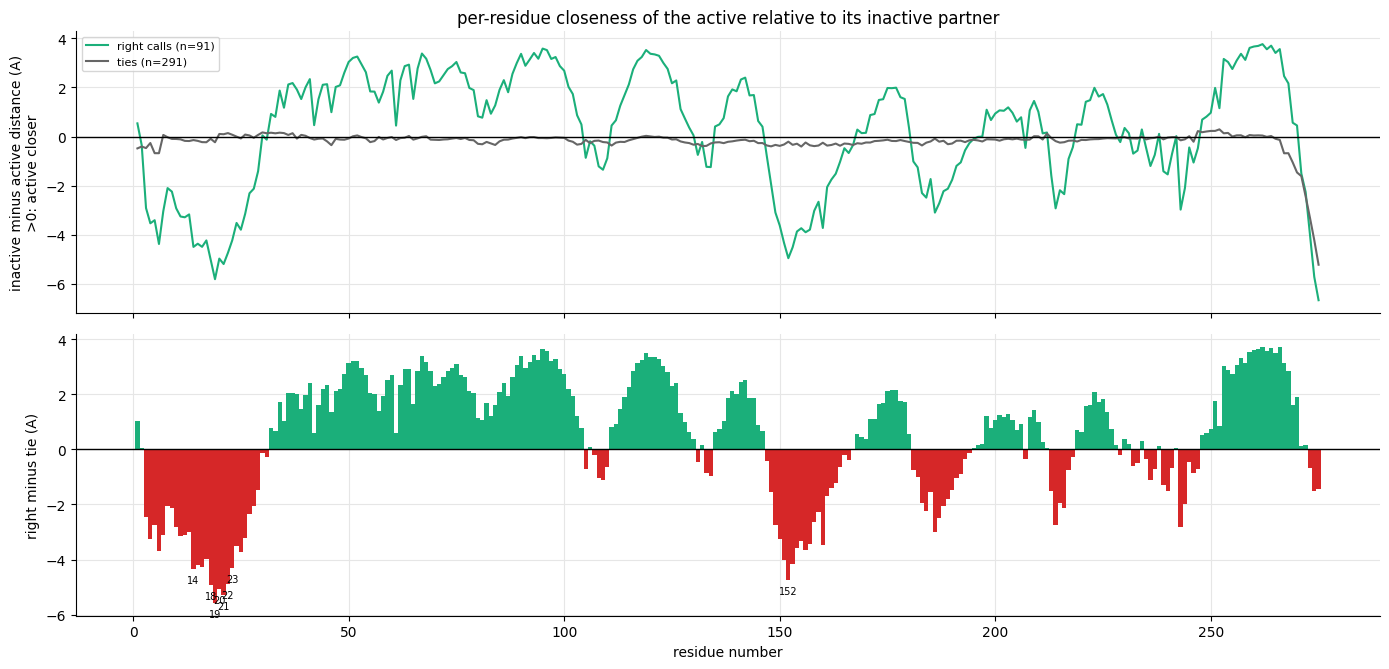

residues where right calls differ most from ties: 19 (-5.57 A), 21 (-5.28 A), 20 (-5.07 A), 18 (-4.92 A), 22 (-4.88 A), 152 (-4.74 A), 14 (-4.35 A), 23 (-4.30 A)
per-pair shift near residues 14-23 (inactive distance minus active distance; negative = inactive closer):
  all cliffs                   right  n= 91 median -0.39 A | inactive >1 A closer 40% | active >1 A closer 9%
  all cliffs                   tie    n=291 median +0.06 A | inactive >1 A closer 12% | active >1 A closer 12%
  all cliffs                   wrong  n= 24 median -0.08 A | inactive >1 A closer 33% | active >1 A closer 12%
  all cliffs: right vs tie Mann-Whitney p=4.4e-11
  without the dominant series  right  n= 13 median +0.00 A | inactive >1 A closer 15% | active >1 A closer 23%
  without the dominant series  tie    n=138 median +0.04 A | inactive >1 A closer 4% | active >1 A closer 12%
  without the dominant series  wrong  n=  3 median -17.26 A | inactive >1 A closer 67% | active >1 A closer 0%
  without the domi

In [15]:
idx=CLIFF.index.values; DELTA=mb[idx]-ma[idx]          # positive: the active is closer to the residue
mask_r=(CLIFF.o_b2=="right").values; mask_t=(CLIFF.o_b2=="tie").values
pr=np.nanmean(DELTA[mask_r],axis=0); pt=np.nanmean(DELTA[mask_t],axis=0); res_num=np.arange(1,len(pr)+1)
fig,axes=plt.subplots(2,1,figsize=(14,6.8),sharex=True)
axes[0].plot(res_num,pr,color=GRN,label=f"right calls (n={int(mask_r.sum())})"); axes[0].plot(res_num,pt,color=NEU,label=f"ties (n={int(mask_t.sum())})")
axes[0].axhline(0,color=BLK,lw=1); axes[0].set_ylabel("inactive minus active distance (A)\n>0: active closer"); axes[0].legend(fontsize=8); axes[0].set_title("per-residue closeness of the active relative to its inactive partner")
dd=pr-pt; axes[1].bar(res_num,dd,width=1.0,color=np.where(dd>0,GRN,CL)); axes[1].axhline(0,color=BLK,lw=1); axes[1].set_xlabel("residue number"); axes[1].set_ylabel("right minus tie (A)")
top=np.argsort(-np.abs(dd))[:8]
for i in top: axes[1].annotate(str(i+1),(i+1,dd[i]),textcoords="offset points",xytext=(0,4 if dd[i]>0 else -10),ha="center",fontsize=7)
plt.tight_layout(); plt.show()
print("residues where right calls differ most from ties:", ", ".join(f"{i+1} ({dd[i]:+.2f} A)" for i in top))

CLIFF["reg_shift"]=np.nanmean(DELTA[:,13:23],axis=1)      # mean over residues 14-23; positive = active closer
print("per-pair shift near residues 14-23 (inactive distance minus active distance; negative = inactive closer):")
for nm,d in [("all cliffs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big])]:
    for g in grp:
        v=d[d.o_b2==g].reg_shift.dropna(); print(f"  {nm:<28} {g:<6} n={len(v):>3} median {v.median():+.2f} A | inactive >1 A closer {100*(v<-1).mean():.0f}% | active >1 A closer {100*(v>1).mean():.0f}%")
    a=d[d.o_b2=="right"].reg_shift.dropna(); b=d[d.o_b2=="tie"].reg_shift.dropna()
    if len(a)>3: print(f"  {nm}: right vs tie Mann-Whitney p={stats.mannwhitneyu(a,b).pvalue:.2g}")

## 9b. Are correct calls a change of binding site?
The profile above suggests the two poses differ in *where* they sit. Clustering all pair members' contact profiles into two sites (k-means) makes that testable: for each outcome, which site the active and the inactive occupy. The sites are labelled from their most contacted residues, so no assumption is made about which is which.

site 0: 316 poses; most contacted residues: 17 (0.97), 25 (0.97), 152 (0.97), 18 (0.96), 150 (0.96), 151 (0.96)
site 1: 49 poses; most contacted residues: 147 (0.98), 105 (0.98), 132 (0.96), 130 (0.94), 131 (0.92), 133 (0.92)


combo,both site 0,both site 1,"active site 0, inactive site 1","active site 1, inactive site 0"
o_b2,,,,
right,77,4,4,6
tie,259,6,17,9
wrong,20,0,0,4


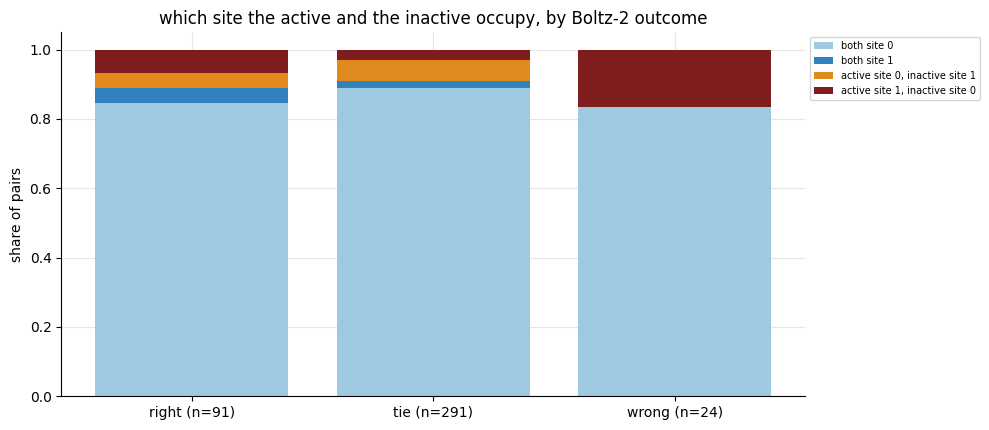

share of pairs whose two members sit in different sites: {'right': np.float64(0.11), 'tie': np.float64(0.09), 'wrong': np.float64(0.17)}
right vs tie, site switch: odds ratio 1.26, Fisher p=0.54


In [16]:
from sklearn.cluster import KMeans
allC=(MD<=5.0).astype(float); okr=~np.isnan(MD).any(1)
km=KMeans(2,n_init=10,random_state=0).fit(allC[okr]); lab=np.full(len(MD),-1); lab[okr]=km.labels_
for k in range(2):
    cen=km.cluster_centers_[k]; top=np.argsort(-cen)[:6]; print(f"site {k}: {int((km.labels_==k).sum())} poses; most contacted residues:", ", ".join(f"{i+1} ({cen[i]:.2f})" for i in top))
CLIFF["site_a"]=[lab[rowof[i]] for i in CLIFF.id_a]; CLIFF["site_b"]=[lab[rowof[i]] for i in CLIFF.id_b]
CLIFF["combo"]=CLIFF.site_a.astype(str)+"->"+CLIFF.site_b.astype(str)
names={"0->0":"both site 0","1->1":"both site 1","0->1":"active site 0, inactive site 1","1->0":"active site 1, inactive site 0"}
ct=pd.crosstab(CLIFF.o_b2,CLIFF.combo).reindex(index=grp).reindex(columns=list(names),fill_value=0); display(ct.rename(columns=names))
fr=ct.div(ct.sum(1),axis=0); fig,ax=plt.subplots(figsize=(10,4.4)); bottom=np.zeros(3)
for c,col in zip(names,["#9ecae1","#3182bd","#e08a1e","#7f1d1d"]):
    ax.bar(range(3),fr[c],bottom=bottom,color=col,label=names[c]); bottom+=fr[c].values
ax.set_xticks(range(3)); ax.set_xticklabels([f"{g} (n={int(ct.loc[g].sum())})" for g in grp]); ax.set_ylabel("share of pairs"); ax.legend(fontsize=7,loc="upper left",bbox_to_anchor=(1.0,1.0)); ax.set_title("which site the active and the inactive occupy, by Boltz-2 outcome")
plt.tight_layout(); plt.show()
sw=lambda g:(CLIFF[CLIFF.o_b2==g].combo.isin(["0->1","1->0"])).mean()
print("share of pairs whose two members sit in different sites:",{g:round(sw(g),2) for g in grp})
r_=CLIFF[CLIFF.o_b2=="right"]; t_=CLIFF[CLIFF.o_b2=="tie"]
a=int(r_.combo.isin(["0->1","1->0"]).sum()); b=len(r_)-a; c_=int(t_.combo.isin(["0->1","1->0"]).sum()); d_=len(t_)-c_
print("right vs tie, site switch: odds ratio %.2f, Fisher p=%.2g"%stats.fisher_exact([[a,b],[c_,d_]]))

## 10. The same profile on the protein itself
The backbone of 588689 (real CA coordinates from a folded pose) drawn as a tube and coloured by the per-residue closeness above: warm where the active sits closer than its inactive partner, cool where it sits farther. Left is the right calls, right is the ties, on one shared scale. These are means and the distribution is heavy-tailed (a few pairs differ by 20 A or more), so section 9 gives medians and shares. The blue stretch at the top left appears in both panels: it is the flexible C-terminal His-tag end, not a difference between outcomes.

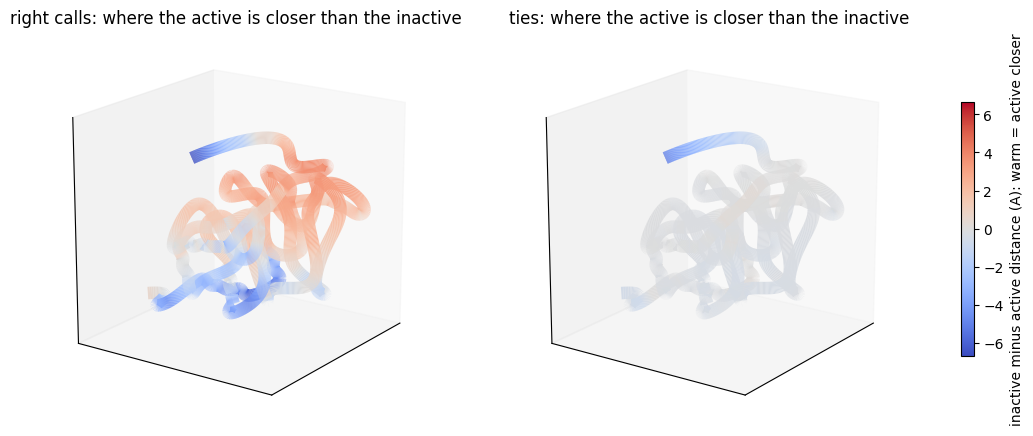

In [17]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.interpolate import splprep, splev
ca=np.load(ROOT/"results/runs/588689/pose_density/ca_colored.npz",allow_pickle=True)["ca"]
def ribbon(ax,ca,val,vmin,vmax):
    n=len(ca); tck,u=splprep([ca[:,0],ca[:,1],ca[:,2]],s=n*3.0,k=3); uu=np.linspace(0,1,n*14); pts=np.array(splev(uu,tck)).T; di=np.interp(uu,np.linspace(0,1,n),val)
    lc=Line3DCollection(np.stack([pts[:-1],pts[1:]],axis=1),cmap="coolwarm",linewidths=9,norm=mpl.colors.Normalize(vmin=vmin,vmax=vmax)); lc.set_array(di[:-1]); ax.add_collection3d(lc)
    mn_,mx_=pts.min(0),pts.max(0); c=(mn_+mx_)/2; rad=(mx_-mn_).max()/2*1.05
    ax.set_xlim(c[0]-rad,c[0]+rad); ax.set_ylim(c[1]-rad,c[1]+rad); ax.set_zlim(c[2]-rad,c[2]+rad); ax.set_box_aspect((1,1,1)); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([]); ax.grid(False); ax.view_init(elev=18,azim=35)
    return lc
lim=float(np.nanmax(np.abs(np.concatenate([pr,pt]))))
fig=plt.figure(figsize=(14,6))
for k,(val,tt) in enumerate([(pr,"right calls"),(pt,"ties")]):
    ax=fig.add_subplot(1,2,k+1,projection="3d"); lc=ribbon(ax,ca,val,-lim,lim); ax.set_title(f"{tt}: where the active is closer than the inactive")
fig.colorbar(lc,ax=fig.axes,shrink=0.55,label="inactive minus active distance (A): warm = active closer"); plt.show()

## 11. Confidence in the correct calls
Boltz-2 confidence differences between the active and its inactive partner, split by outcome. If a correct large delta went with a more confident pose for the active, the right box would sit above zero.

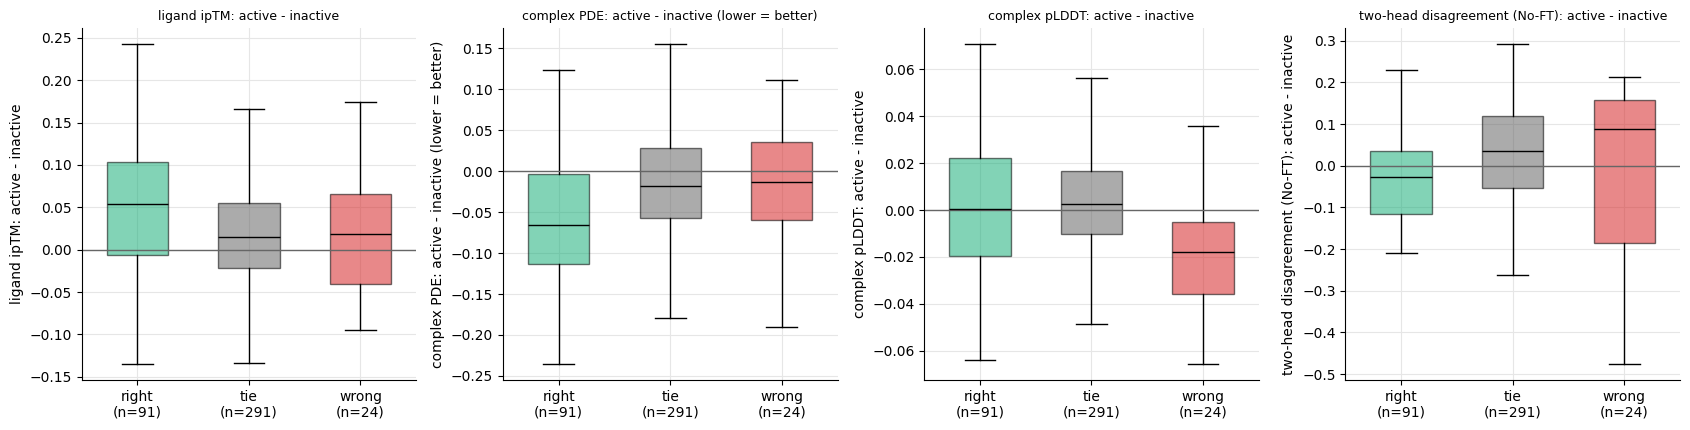

,median (right),median (tie),median (wrong),right vs tie p (all),right calls outside dominant series,right vs tie p (outside)
signal,,,,,,
ligand ipTM: active - inactive,0.0541,0.0152,0.0191,0.0002,13,0.6025
complex PDE: active - inactive (lower = better),-0.0655,-0.0184,-0.0133,0.0000,13,0.5842
complex pLDDT: active - inactive,0.0006,0.0025,-0.0180,0.3138,13,0.8138
two-head disagreement (No-FT): active - inactive,-0.0273,0.0344,0.0879,0.0000,13,0.1666


In [18]:
cf=[("c_ligand_iptm","ligand ipTM: active - inactive"),("c_complex_pde","complex PDE: active - inactive (lower = better)"),("c_complex_plddt","complex pLDDT: active - inactive"),("c_disagree_noft","two-head disagreement (No-FT): active - inactive")]
fig,axes=plt.subplots(1,4,figsize=(17,4.4)); rows=[]
for ax,(c,l) in zip(axes,cf):
    boxes(ax,[CLIFF[CLIFF.o_b2==g][c].dropna() for g in grp],[f"{g}\n(n={int((CLIFF.o_b2==g).sum())})" for g in grp],[OC[g] for g in grp],l,l)
    a=CLIFF[CLIFF.o_b2=="right"][c].dropna(); b=CLIFF[CLIFF.o_b2=="tie"][c].dropna(); a2=CLIFF[(CLIFF.o_b2=="right")&(~CLIFF.big)][c].dropna(); b2=CLIFF[(CLIFF.o_b2=="tie")&(~CLIFF.big)][c].dropna()
    rows.append((l,a.median(),b.median(),CLIFF[CLIFF.o_b2=="wrong"][c].median(),stats.mannwhitneyu(a,b).pvalue,len(a2),stats.mannwhitneyu(a2,b2).pvalue if len(a2)>3 else np.nan))
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows,columns=["signal","median (right)","median (tie)","median (wrong)","right vs tie p (all)","right calls outside dominant series","right vs tie p (outside)"]).set_index("signal").round(4))

## 12. When a model makes a big call, how much should you trust it?
Selective accuracy. Rank the pairs by the *size* of each signal's difference, keep the top fraction, and measure how often the sign is right in that fraction. A trustworthy large delta would give accuracy rising as coverage falls. The size and lipophilicity baselines are ranked the same way, so this compares a model's large delta with a large property difference on equal footing. The far left of each curve rests on few pairs (the top 5% of the 154 pairs outside the dominant series is 8 pairs), so read the trend, not individual points.

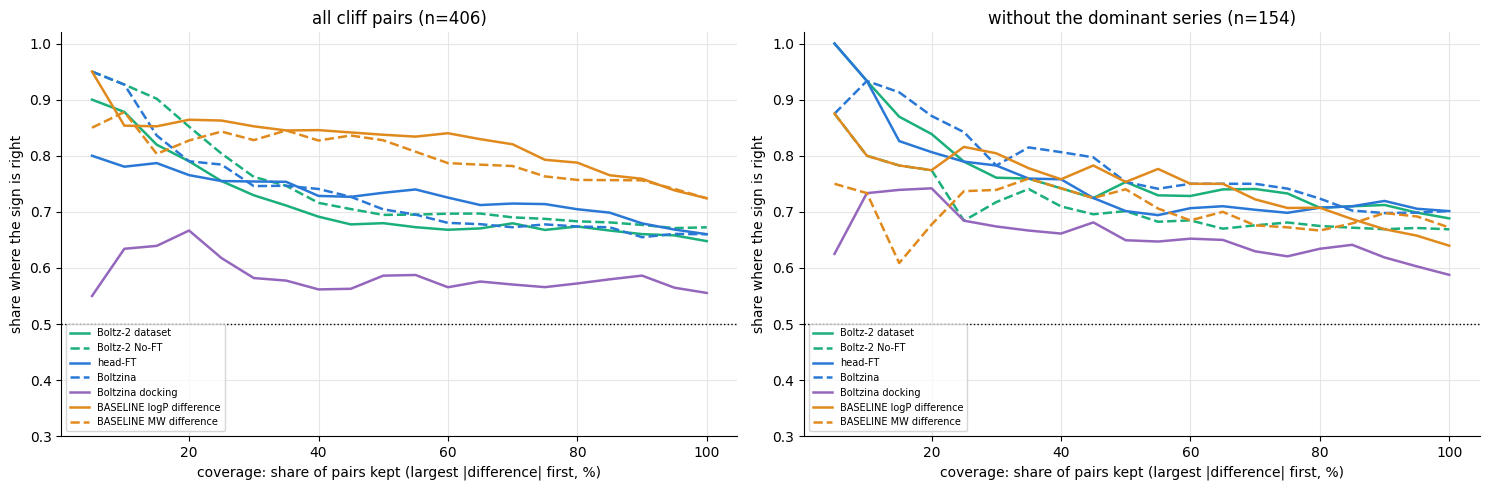

In [19]:
def sel_curve(d,col,fr=np.linspace(0.05,1.0,20)):
    x=d[col].dropna().values; s=np.sign(x)[np.argsort(-np.abs(x))]; out=[]
    for f in fr:
        k=max(1,int(round(f*len(s)))); t=s[:k]; out.append(((t>0).sum()+0.5*(t==0).sum())/k)
    return fr,np.array(out)
SIG=[("d_score_boltz2","Boltz-2 dataset",GRN,"-"),("d_base_noft","Boltz-2 No-FT",GRN,"--"),("d_ft300","head-FT",CO,"-"),("d_score_boltzina","Boltzina",CO,"--"),("d_docking_score_boltzina","Boltzina docking","#9467bd","-"),
     ("dp_logP","BASELINE logP difference","#e08a1e","-"),("dp_MW","BASELINE MW difference","#e08a1e","--")]
fig,axes=plt.subplots(1,2,figsize=(15,5))
for ax,(nm,d) in zip(axes,[("all cliff pairs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big])]):
    for col,l,c,ls in SIG:
        fr,a=sel_curve(d,col); ax.plot(100*fr,a,color=c,ls=ls,label=l,lw=1.8)
    ax.axhline(0.5,color=BLK,lw=1,ls=":"); ax.set_xlabel("coverage: share of pairs kept (largest |difference| first, %)"); ax.set_ylabel("share where the sign is right"); ax.set_ylim(0.3,1.02); ax.set_title(f"{nm} (n={len(d)})"); ax.legend(fontsize=7,loc="lower left")
plt.tight_layout(); plt.show()

## 13. Are the correct calls the cleaner cliffs?
The inactive partner's primary-screen Z-score by outcome. If the pairs the head gets right are the ones where the partner is a clean zero, and the wrong calls are partners with partial activity, the 'errors' are partly real signal. This is per pair, so partners can repeat; the dominant series is shown separately.

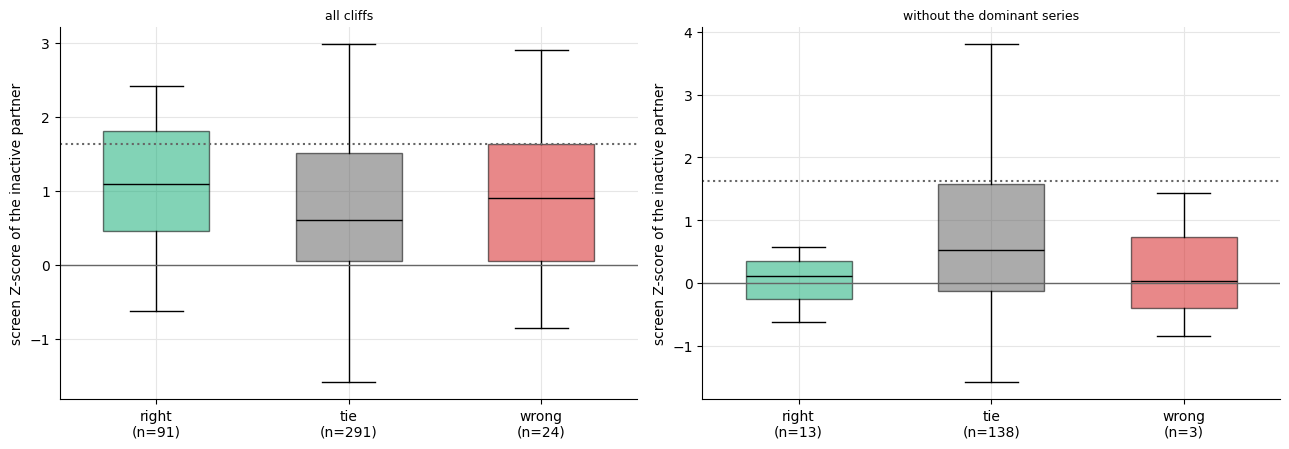

all: median partner Z right 1.10 (n=91) | tie 0.61 | wrong 0.90 (n=24) | right vs wrong p=0.14
without dominant series: median partner Z right 0.11 (n=13) | tie 0.52 | wrong 0.04 (n=3)


In [20]:
CLIFF["partner_z"]=ZS.reindex(CLIFF.id_b.values).values
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for ax,(nm,d) in zip(axes,[("all cliffs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big])]):
    gs=[d[d.o_b2==g].partner_z.dropna() for g in grp]; boxes(ax,gs,[f"{g}\n(n={len(x)})" for g,x in zip(grp,gs)],[OC[g] for g in grp],"screen Z-score of the inactive partner",nm)
    ax.axhline(INA_Z.quantile(0.99),ls=":",color=NEU)
plt.tight_layout(); plt.show()
for nm,d in [("all",CLIFF),("without dominant series",CLIFF[~CLIFF.big])]:
    a=d[d.o_b2=="right"].partner_z.dropna(); b=d[d.o_b2=="wrong"].partner_z.dropna(); t=d[d.o_b2=="tie"].partner_z.dropna()
    print(f"{nm}: median partner Z right {a.median():.2f} (n={len(a)}) | tie {t.median():.2f} | wrong {b.median():.2f} (n={len(b)})" + (f" | right vs wrong p={stats.mannwhitneyu(a,b).pvalue:.2g}" if len(a)>3 and len(b)>3 else ""))

## 14. If the Boltz-2 head is right, are the other methods?
Conditional detection: for pairs the head calls right, ties on, or gets wrong, the share where each other signal ranks the active higher. Agreement conditional on being right would mean a shared, reproducible signal.

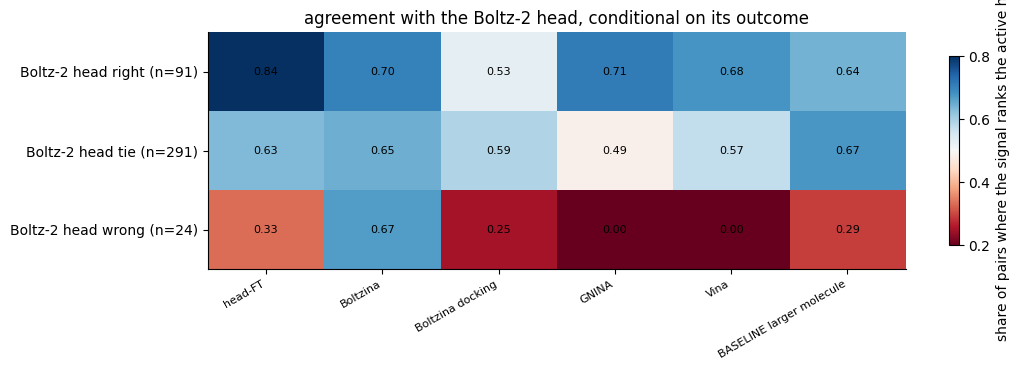

In [21]:
cols=[("ft300","head-FT"),("score_boltzina","Boltzina"),("docking_score_boltzina","Boltzina docking"),("score_gnina","GNINA"),("score_vina","Vina")]
def rate(x):
    x=x.dropna(); return ((x>0).sum()+0.5*(x==0).sum())/len(x) if len(x) else np.nan
mat=np.array([[rate(CLIFF[CLIFF.o_b2==g]["d_"+m]) for m,_ in cols]+[rate(CLIFF[CLIFF.o_b2==g].dp_heavy)] for g in grp],float)
names=[l for _,l in cols]+["BASELINE larger molecule"]
fig,ax=plt.subplots(figsize=(11,3.8)); im=ax.imshow(mat,cmap="RdBu",vmin=0.2,vmax=0.8,aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=30,ha="right",fontsize=8); ax.set_yticks(range(3)); ax.set_yticklabels([f"Boltz-2 head {g} (n={int((CLIFF.o_b2==g).sum())})" for g in grp])
for i in range(3):
    for j in range(len(names)):
        if np.isfinite(mat[i,j]): ax.text(j,i,f"{mat[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,shrink=0.8,label="share of pairs where the signal ranks the active higher"); ax.set_title("agreement with the Boltz-2 head, conditional on its outcome"); plt.tight_layout(); plt.show()

## 15. Which chemical series carry the correct calls?
Right calls per series, and the scaffold of the biggest series. A pattern that lives in one series is a statement about that series.

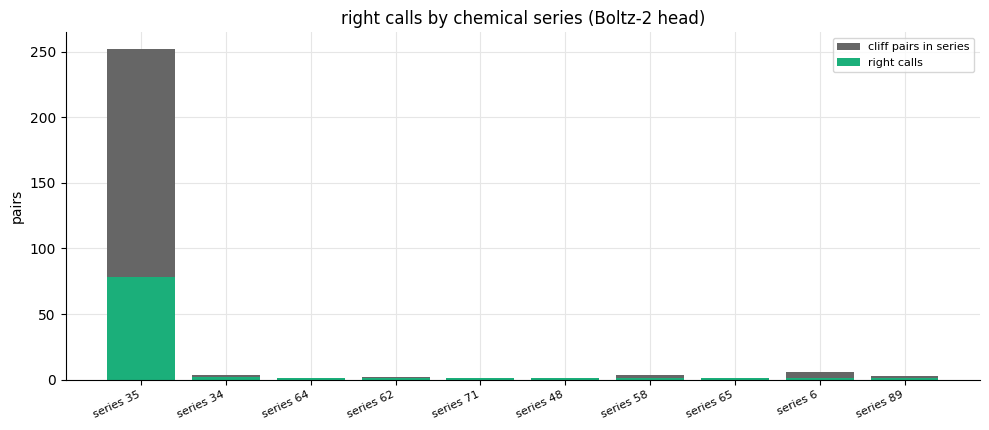

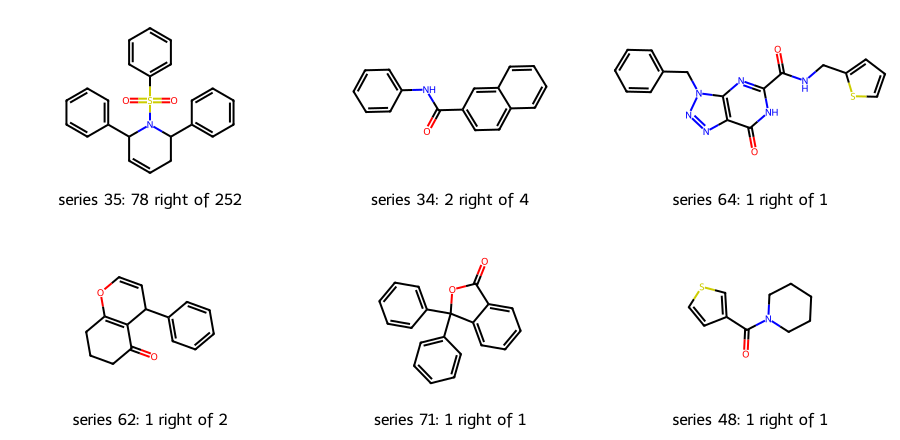

right calls: 91; distinct actives 27; distinct series 13; share in the dominant series 86%


In [22]:
R=CLIFF[CLIFF.o_b2=="right"]; sc=CLIFF.groupby("series").size(); rc=R.groupby("series").size().reindex(sc.index).fillna(0)
tb=pd.DataFrame({"cliffs":sc,"right":rc}).sort_values("right",ascending=False).head(10)
fig,ax=plt.subplots(figsize=(10,4.4)); x=np.arange(len(tb)); ax.bar(x,tb.cliffs,color=NEU,label="cliff pairs in series"); ax.bar(x,tb.right,color=GRN,label="right calls")
ax.set_xticks(x); ax.set_xticklabels([f"series {i}" for i in tb.index],rotation=25,ha="right",fontsize=8); ax.set_ylabel("pairs"); ax.legend(fontsize=8); ax.set_title("right calls by chemical series (Boltz-2 head)")
plt.tight_layout(); plt.show()
from rdkit.Chem.Scaffolds import MurckoScaffold
mols=[];leg=[]
for s_ in tb.index[:6]:
    smi=CLIFF[CLIFF.series==s_].smiles_a.iloc[0]; mols.append(Chem.MolFromSmiles(MurckoScaffold.MurckoScaffoldSmiles(smiles=smi)) or Chem.MolFromSmiles(smi)); leg.append(f"series {s_}: {int(tb.loc[s_,'right'])} right of {int(tb.loc[s_,'cliffs'])}")
display(Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(300,220),legends=leg,returnPNG=False))
print(f"right calls: {len(R)}; distinct actives {R.id_a.nunique()}; distinct series {R.series.nunique()}; share in the dominant series {100*R.big.mean():.0f}%")

## Conclusions (target 588689)

Of 406 cliff pairs, the Boltz-2 affinity head (dataset score or our No-FT, without contradiction) makes a large correct call on 91, a large wrong call on 24, and ties on 291. Everything below is an association in observational pairs, and p-values treat pairs as independent, so they are optimistic.

**1. The correct calls are few, concentrated and lean on reused partners.** The 91 right calls involve 27 distinct actives, 30 distinct inactive partners and 13 series, and 78 of them (86%) sit in the one dominant series; the three most reused inactive partners account for 26 of the calls. Outside that series there are 13. The strongest deltas are at the low end of the similarity range (0.60 to 0.66), but correct calls are not confined there: the right rate is 23%, 19% and 27% across the three similarity bins, and at Tanimoto >= 0.8 there are 14 right calls against 1 wrong.

**2. Different methods are not finding the same pairs.** Apart from the two Boltz-2 scores (same model, different pose: 31 shared right calls against 9.0 expected) and head-FT (whose 13 right calls overlap those of Boltz-2, No-FT and Boltzina more than chance, though not those of docking), right-call sets overlap no more than chance: Boltz-2 and Boltzina 7 against 5.6 expected, No-FT and Boltzina 6 against 7.6, Boltz-2 and docking 9 against 7.9. Only 14 pairs are called right by three or more of five modalities and none by all five. In percentile terms head-FT makes only 14 large calls (13 right, none of the right ones in the dominant series), but that count is depressed by the percentile scale: fine-tuning places whole series near the top of the ranking, so a gap above 0.3 is often impossible. It is not evidence that head-FT is less sensitive; with thresholds calibrated on both-active pairs its sensitivity is within noise of No-FT's (notebook 16).

**3. Size and lipophilicity explain some of it, not all.** Right calls do not have larger heavy-atom or logP differences than ties (medians 0 vs +1 atoms, p=0.43; +0.64 vs +0.50 logP, p=0.33), but a larger mass difference (+42 vs +22 Da, p=0.0002), which points at halogen swaps: every C.Br to C.Cl pair (5 of 5) and 4 of 7 Br to F pairs are called right, all in the dominant series, while removing a chlorine (10 pairs) or placing one at a different position (4 pairs) is never called right. The score delta correlates with the logP and MW difference across all pairs (rho 0.13 to 0.30) but not outside the dominant series (rho -0.10 to 0.04). Where the trivial explanation is unavailable (active neither larger nor greasier, 85 pairs) the picture splits: No-FT is right 12 times and wrong 5 (9 actives, 2 series), Boltzina right 8 and wrong 1 (8 actives, 5 series), while the Boltz-2 dataset score is right 2 and wrong 9. Boltzina is the one modality whose non-trivial calls span several series.

**4. The chemistry of the right calls is mostly substituent bulk and halogen weight, with a few distinct groups.** The most similar correct pairs are single-substituent swaps in the dominant series (bromine over fluorine, tert-butyl over chlorine or methyl). Outside it, correct calls (by the Boltz-2 head or Boltzina) include a thiourea inserted into an amide (No-FT 0.99 against 0.56), a maleimide against its saturated succinimide, and a hydroxy against a methoxy naphthamide. This is not recognition of reactive or interference groups in general: right-call actives carry a structural alert in 5% of pairs against 25% of ties.

**5. Pose and confidence differ in the right calls, but the evidence is one series.** Right calls have more dissimilar poses (median contact dissimilarity 0.36 vs 0.24 for ties and 0.22 for wrong calls), the inactive sits more than 1 A closer to residues 14-23 in 40% of right calls against 12% of ties (33% of wrong calls, so large deltas in either direction accompany a pose difference there), and the active is more confident (ligand ipTM gap +0.054 vs +0.015, lower PDE, heads agreeing more). It is not a change of binding site: pairs whose members sit in different sites are 11% of right calls and 9% of ties (p=0.54). Outside the dominant series none of these is significant, but there are only 13 right calls to test with.

**6. A big delta is more trustworthy than a small one, but no more than a big property difference.** As coverage falls to the top 5-10% of pairs by |delta|, accuracy rises from about 0.65-0.70 to roughly 0.8-0.95 for the models. A large logP or MW difference is at least as reliable, and stays above the models over most of the range when all pairs are used. Outside the dominant series the models are level with the baselines, but the top 5-10% is only 8 to 15 pairs.

**What can and cannot be said.** It can be said that the correct large calls exist, that a large model delta is a better-than-average bet, and that the strongest examples are interpretable substituent effects. It cannot be said that they show the models understand binding beyond substituent bulk and lipophilicity: they are concentrated in one series, reuse a few partners, are not shared across methods, and are matched by a large property difference.

**Caveats.** One target and one dominant series. The pair set is anchored on held-out actives. The 0.3 percentile threshold is arbitrary: from 0.2 to 0.5, 78-86% of right calls stay in the dominant series and the ratio of right to wrong calls rises from about 2.4 to 1 at 0.2 to 18 to 1 at 0.5, so larger deltas are more reliable but no less concentrated. Labels come from a single-concentration screen. Several tests have 13 or fewer right calls outside the dominant series.